In [ ]:
!pip install transformers pillow requests

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import pandas as pd
from PIL import Image
import requests
from io import BytesIO
from transformers import CLIPProcessor, CLIPModel

To Load the trained BERT Model

In [ ]:
# Extract the bert_fakeddit_model.zip file to the designated directory
# The -o flag means overwrite existing files without prompting.
!unzip -o /content/bert_fakeddit_model.zip -d /content/bert_fakeddit_model/

# After extraction, list the contents of the extracted directory to confirm files
!ls -F /content/bert_fakeddit_model/

Archive:  /content/bert_fakeddit_model.zip
   creating: /content/bert_fakeddit_model/bert_fakeddit_model/
  inflating: /content/bert_fakeddit_model/bert_fakeddit_model/tokenizer_config.json  
  inflating: /content/bert_fakeddit_model/bert_fakeddit_model/tokenizer.json  
  inflating: /content/bert_fakeddit_model/bert_fakeddit_model/config.json  
  inflating: /content/bert_fakeddit_model/bert_fakeddit_model/model.safetensors  
bert_fakeddit_model/


In [ ]:
from transformers import BertForSequenceClassification, BertTokenizer
import os

# The previous errors indicate that the 'transformers' library cannot find
# the necessary model files (like config.json) directly in the specified 'model_path'.
# This is likely because the 'bert_fakeddit_model.zip' file was reported as corrupted
# or invalid, and thus the model was never properly extracted.
# Please ensure you have uploaded a valid 'bert_fakeddit_model.zip' file to /content/
# and then run the unzip command.

# After successful extraction, 'model_path' should point to the directory
# containing files like config.json, pytorch_model.bin, and vocab.txt.
# IMPORTANT: 'model_path' should be a directory, not the .zip file itself.
# For example, if you extract it to '/content/bert_fakeddit_model_extracted/'
# and the model files are directly inside, then model_path = '/content/bert_fakeddit_model_extracted/'
model_path = "/content/bert_fakeddit_model/bert_fakeddit_model" # Change this to the *extracted directory path*

# This line will still fail until the model files are properly extracted and present at model_path.
model = BertForSequenceClassification.from_pretrained(model_path)
tokenizer = BertTokenizer.from_pretrained(model_path)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [ ]:
!ls -F /content/bert_fakeddit_model_extracted/

ls: cannot access '/content/bert_fakeddit_model_extracted/': No such file or directory


In [ ]:
# Extract the bert_fakeddit_model.zip file to the designated directory
!unzip -o /content/bert_fakeddit_model.zip -d /content/bert_fakeddit_model_extracted/

# After extraction, list the contents of the extracted directory to confirm files and identify the correct nested path if any
!ls -F /content/bert_fakeddit_model_extracted/

Archive:  /content/bert_fakeddit_model.zip
   creating: /content/bert_fakeddit_model_extracted/bert_fakeddit_model/
  inflating: /content/bert_fakeddit_model_extracted/bert_fakeddit_model/tokenizer_config.json  
  inflating: /content/bert_fakeddit_model_extracted/bert_fakeddit_model/tokenizer.json  
  inflating: /content/bert_fakeddit_model_extracted/bert_fakeddit_model/config.json  
  inflating: /content/bert_fakeddit_model_extracted/bert_fakeddit_model/model.safetensors  
bert_fakeddit_model/


In [ ]:
# Extract the bert_fakeddit_model.zip file
!unzip /content/bert_fakeddit_model.zip -d /content/bert_fakeddit_model_extracted/

# After extraction, run the 'ls' command again to see the contents
!ls -F /content/bert_fakeddit_model_extracted/

Archive:  /content/bert_fakeddit_model.zip
replace /content/bert_fakeddit_model_extracted/bert_fakeddit_model/tokenizer_config.json? [y]es, [n]o, [A]ll, [N]one, [r]ename: bert_fakeddit_model/


Preparing for multimodal data

In [ ]:
import pandas as pd

df_raw = pd.read_csv("/content/multimodal_train.tsv", sep='\t')

print(df_raw.columns)
df_raw.head()

Index(['author', 'clean_title', 'created_utc', 'domain', 'hasImage', 'id',
       'image_url', 'linked_submission_id', 'num_comments', 'score',
       'subreddit', 'title', 'upvote_ratio', '2_way_label', '3_way_label',
       '6_way_label'],
      dtype='object')


,author,clean_title,created_utc,domain,hasImage,id,image_url,linked_submission_id,num_comments,score,subreddit,title,upvote_ratio,2_way_label,3_way_label,6_way_label
0,Alexithymia,my walgreens offbrand mucinex was engraved wit...,1.551641e+09,i.imgur.com,True,awxhir,https://external-preview.redd.it/WylDbZrnbvZdB...,NaN,2.0,12,mildlyinteresting,My Walgreens offbrand Mucinex was engraved wit...,0.84,1,0,0
1,VIDCAs17,this concerned sink with a tiny hat,1.534727e+09,i.redd.it,True,98pbid,https://preview.redd.it/wsfx0gp0f5h11.jpg?widt...,NaN,2.0,119,pareidolia,This concerned sink with a tiny hat,0.99,0,2,2
2,prometheus1123,hackers leak emails from uae ambassador to us,1.496511e+09,aljazeera.com,True,6f2cy5,https://external-preview.redd.it/6fNhdbc6K1vFA...,NaN,1.0,44,neutralnews,Hackers leak emails from UAE ambassador to US,0.92,1,0,0
3,NaN,puppy taking in the view,1.471341e+09,i.imgur.com,True,4xypkv,https://external-preview.redd.it/HLtVNhTR6wtYt...,NaN,26.0,250,photoshopbattles,PsBattle: Puppy taking in the view,0.95,1,0,0
4,3rikR3ith,i found a face in my sheet music too,1.525318e+09,i.redd.it,True,8gnet9,https://preview.redd.it/ri7ut2wn8kv01.jpg?widt...,NaN,2.0,13,pareidolia,I found a face in my sheet music too!,0.84,0,2,2


In [ ]:
text_column = 'title'
image_column = 'image_url'
label_column = '2_way_label'

multi_df = df_raw[[text_column, image_column, label_column]]

multi_df = multi_df.rename(columns={
    text_column: "text",
    image_column: "image",
    label_column: "label"
})

multi_df.head()

,text,image,label
0,My Walgreens offbrand Mucinex was engraved wit...,https://external-preview.redd.it/WylDbZrnbvZdB...,1
1,This concerned sink with a tiny hat,https://preview.redd.it/wsfx0gp0f5h11.jpg?widt...,0
2,Hackers leak emails from UAE ambassador to US,https://external-preview.redd.it/6fNhdbc6K1vFA...,1
3,PsBattle: Puppy taking in the view,https://external-preview.redd.it/HLtVNhTR6wtYt...,1
4,I found a face in my sheet music too!,https://preview.redd.it/ri7ut2wn8kv01.jpg?widt...,0


In [ ]:
multi_df = multi_df.dropna(subset=["text", "image", "label"])

multi_df["text"] = multi_df["text"].astype(str)
multi_df["image"] = multi_df["image"].astype(str)

multi_df = multi_df[multi_df["text"].str.strip() != ""]
multi_df = multi_df[multi_df["image"].str.strip() != ""]

print(multi_df.shape)

(562466, 3)


In [ ]:
import re

def clean_text(text):
    text = text.lower() # Convert to lowercase
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE) # Remove URLs
    text = re.sub(r'[^a-zA-Z\s]', '', text) # Remove special characters
    return text.strip()

multi_df["text"] = multi_df["text"].apply(clean_text)

In [ ]:
multi_df["label"].value_counts()

,count
label,
0,341460
1,221006


In [ ]:
multi_df.to_csv("/content/clean_fakeddit_multimodal.csv", index=False)

Load and display images

Text: my walgreens offbrand mucinex was engraved with the letters mucinex but in a different order
Label: 1
Image: https://external-preview.redd.it/WylDbZrnbvZdBpgfa3ntxYf17CBHndiJWHylVm2j_nY.jpg?width=320&crop=smart&auto=webp&s=449659a10792de4d55c2f27d2176fdc8bc66e72a


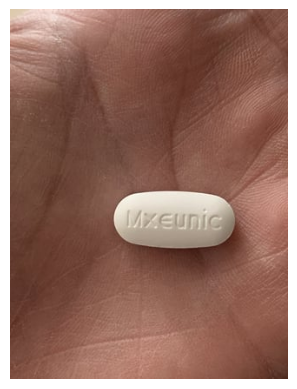

In [ ]:
import requests
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt

def load_image(image_path_or_url):
    response = requests.get(image_path_or_url)
    response.raise_for_status() # Add this line to raise an HTTPError for bad responses (4xx or 5xx)
    image = Image.open(BytesIO(response.content)).convert("RGB")
    return image

sample = multi_df.iloc[0]

print("Text:", sample["text"])
print("Label:", sample["label"])
print("Image:", sample["image"])

# Ensure this part is also inside a try-except block if you want to display only valid images
try:
    image = load_image(sample["image"])
    plt.imshow(image)
    plt.axis("off")
    plt.show()
except Exception as e:
    print(f"Failed to display sample image: {e}")

Text: my walgreens offbrand mucinex was engraved with the letters mucinex but in a different order
Label: 1


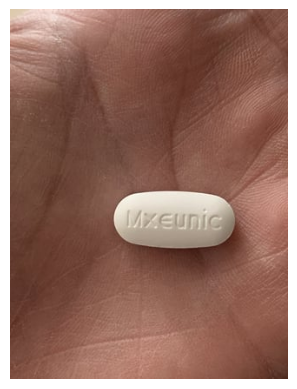

Text: this concerned sink with a tiny hat
Label: 0
Error: Network issue while fetching image for index 1. URL: https://preview.redd.it/wsfx0gp0f5h11.jpg?width=320&crop=smart&auto=webp&s=6267a3ae11e616453e129c58ae34635b98c4ab37. Error: 404 Client Error: Not Found for url: https://preview.redd.it/wsfx0gp0f5h11.jpg?width=320&crop=smart&auto=webp&s=6267a3ae11e616453e129c58ae34635b98c4ab37
Text: hackers leak emails from uae ambassador to us
Label: 1


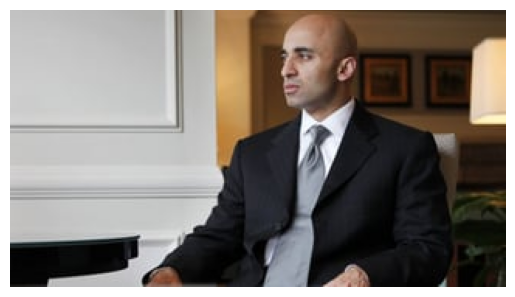

Text: psbattle puppy taking in the view
Label: 1


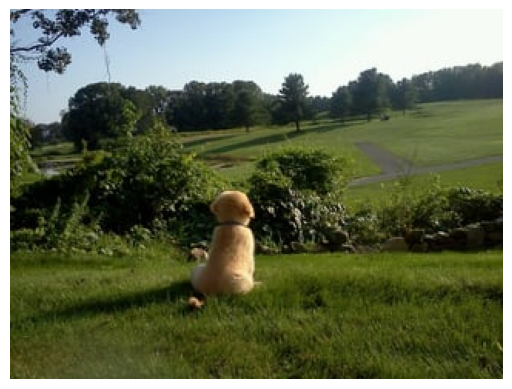

Text: i found a face in my sheet music too
Label: 0
Error: Network issue while fetching image for index 4. URL: https://preview.redd.it/ri7ut2wn8kv01.jpg?width=320&crop=smart&auto=webp&s=d44a419480c2073a2f0f3fa5f3701b308271331d. Error: 404 Client Error: Not Found for url: https://preview.redd.it/ri7ut2wn8kv01.jpg?width=320&crop=smart&auto=webp&s=d44a419480c2073a2f0f3fa5f3701b308271331d


In [ ]:
for i in range(5):
    sample = multi_df.iloc[i]

    print("Text:", sample["text"])
    print("Label:", sample["label"])

    try:
        image = load_image(sample["image"])
        plt.imshow(image)
        plt.axis("off")
        plt.show()
    except Image.UnidentifiedImageError as e:
        print(f"Error: Could not identify image file for index {i}. URL: {sample['image']}. Error: {e}")
    except requests.exceptions.RequestException as e:
        print(f"Error: Network issue while fetching image for index {i}. URL: {sample['image']}. Error: {e}")
    except Exception as e:
        print(f"An unexpected error occurred for index {i}. URL: {sample['image']}. Error: {e}")

Class Distribution

In [ ]:
label_counts = multi_df["label"].value_counts().sort_index()
print(label_counts)

label_percent = multi_df["label"].value_counts(normalize=True).sort_index() * 100
print(label_percent)

label
0    341460
1    221006
Name: count, dtype: int64
label
0    60.707669
1    39.292331
Name: proportion, dtype: float64


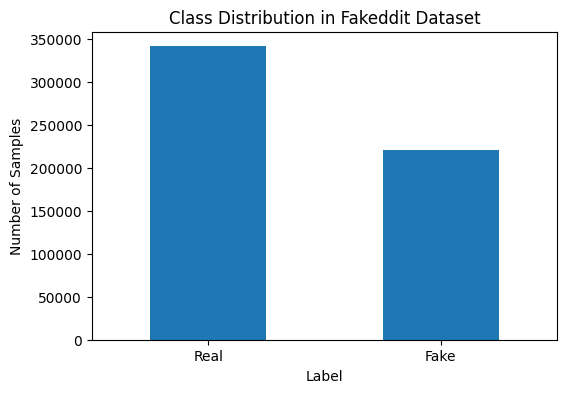

In [ ]:
label_counts.plot(kind="bar", figsize=(6,4))

plt.title("Class Distribution in Fakeddit Dataset")
plt.xlabel("Label")
plt.ylabel("Number of Samples")
plt.xticks([0, 1], ["Real", "Fake"], rotation=0)
plt.show()

CLIP preprocessing

In [ ]:
multi_df = pd.read_csv("/content/clean_fakeddit_multimodal.csv")

multi_df.head()

,text,image,label
0,my walgreens offbrand mucinex was engraved wit...,https://external-preview.redd.it/WylDbZrnbvZdB...,1
1,this concerned sink with a tiny hat,https://preview.redd.it/wsfx0gp0f5h11.jpg?widt...,0
2,hackers leak emails from uae ambassador to us,https://external-preview.redd.it/6fNhdbc6K1vFA...,1
3,psbattle puppy taking in the view,https://external-preview.redd.it/HLtVNhTR6wtYt...,1
4,i found a face in my sheet music too,https://preview.redd.it/ri7ut2wn8kv01.jpg?widt...,0


In [ ]:
clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
device="cuda" if torch.cuda.is_available() else "cpu"
clip_model = clip_model.to(device)
clip_model.eval()

print(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

...

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

cpu


In [ ]:
from PIL import Image
from io import BytesIO
import requests
import time

def load_image(image_url):
    try:
        response = requests.get(
            image_url,
            timeout=10,
            headers={"User-Agent": "Mozilla/5.0"}
        )

        if response.status_code == 429:
            print("Too many requests. Waiting...")
            time.sleep(5)

            response = requests.get(
                image_url,
                timeout=10,
                headers={"User-Agent": "Mozilla/5.0"}
            )

        response.raise_for_status()

        image = Image.open(BytesIO(response.content)).convert("RGB")
        return image

    except Exception as e:
        print("Image failed:", image_url)
        print("Error:", e)

        return Image.new("RGB", (224, 224), color="white")

In [ ]:
sample = multi_df.iloc[0]
text = sample["text"]
image = load_image(sample["image"])

#Process it for CLIP
inputs = clip_processor(
    text=[text],
    images=image,
    return_tensors="pt",
    padding=True,
    truncation=True
)

inputs = {key: value.to(device) for key, value in inputs.items()}

In [ ]:
#Extract features
with torch.no_grad():
    outputs = clip_model(**inputs)

    text_features = outputs.text_embeds
    image_features = outputs.image_embeds

print("Text feature shape:", text_features.shape)
print("Image feature shape:", image_features.shape)

Text feature shape: torch.Size([1, 512])
Image feature shape: torch.Size([1, 512])


Create a CLIP Dataset Class

In [ ]:
import torch
from torch.utils.data import Dataset

In [ ]:
import requests
from PIL import Image
import torch
from torch.utils.data import Dataset
from torch.utils.data.dataloader import default_collate


class FakedditCLIPDataset(Dataset):
    def __init__(self, dataframe, processor):
        # Store the original indices that correspond to the rows of the dataframe *before* reset_index
        self.original_small_test_df_indices = dataframe.index.tolist()
        self.dataframe = dataframe.reset_index(drop=True) # self.dataframe will have 0-based index
        self.processor = processor

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx): # idx here is the 0-based index of self.dataframe
        row = self.dataframe.iloc[idx]

        text = row["text"]
        image_url = row["image"]
        label = int(row["label"])

        try:
            image = load_image(image_url)
            inputs = self.processor(
                text=text,
                images=image,
                return_tensors="pt",
                padding="max_length",
                truncation=True,
                max_length=77
            )

            item = {
                "input_ids": inputs["input_ids"].squeeze(0),
                "attention_mask": inputs["attention_mask"].squeeze(0),
                "pixel_values": inputs["pixel_values"].squeeze(0),
                "label": torch.tensor(label, dtype=torch.long),
                # Crucially, return the *original index from small_test_df* for this row
                "original_idx_from_small_test_df": torch.tensor(self.original_small_test_df_indices[idx], dtype=torch.long)
            }
            return item
        except (requests.exceptions.RequestException, Image.UnidentifiedImageError, KeyError) as e:
            # print(f"Skipping sample due to processing error: {e} for URL: {image_url}") # load_image already prints errors
            return None # Return None if image loading or processing fails

def custom_collate_fn(batch):
    # Filter out None values from the batch
    batch = list(filter(lambda x: x is not None, batch))
    if not batch:  # If the batch is empty after filtering, return None
        return None
    return default_collate(batch)

Text: my walgreens offbrand mucinex was engraved with the letters mucinex but in a different order
Label: 1
Image: https://external-preview.redd.it/WylDbZrnbvZdBpgfa3ntxYf17CBHndiJWHylVm2j_nY.jpg?width=320&crop=smart&auto=webp&s=449659a10792de4d55c2f27d2176fdc8bc66e72a


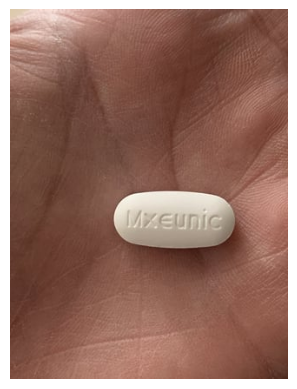

In [ ]:
import requests
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt
import time # Import time module

def load_image(image_path_or_url):
    response = requests.get(image_path_or_url)
    response.raise_for_status() # Add this line to raise an HTTPError for bad responses (4xx or 5xx)
    image = Image.open(BytesIO(response.content)).convert("RGB")
    time.sleep(0.1) # Add a small delay (e.g., 0.1 seconds) after each successful request
    return image

sample = multi_df.iloc[0]

print("Text:", sample["text"])
print("Label:", sample["label"])
print("Image:", sample["image"])

# Ensure this part is also inside a try-except block if you want to display only valid images
try:
    image = load_image(sample["image"])
    plt.imshow(image)
    plt.axis("off")
    plt.show()
except Exception as e:
    print(f"Failed to display sample image: {e}")

In [ ]:
#Train-Test Split
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    multi_df,
    test_size=0.2,
    random_state=42,
    stratify=multi_df["label"]
)

print(train_df.shape)
print(test_df.shape)

(449972, 3)
(112494, 3)


In [ ]:
#Create Dataset objects
train_dataset = FakedditCLIPDataset(train_df, clip_processor)
test_dataset = FakedditCLIPDataset(test_df, clip_processor)

In [ ]:
#Test one Item
sample = train_dataset[0]

print(sample.keys())
print(sample["input_ids"].shape)
print(sample["attention_mask"].shape)
print(sample["pixel_values"].shape)
print(sample["label"])

dict_keys(['input_ids', 'attention_mask', 'pixel_values', 'label', 'original_idx_from_small_test_df'])
torch.Size([77])
torch.Size([77])
torch.Size([3, 224, 224])
tensor(1)


 Create DataLoader for CLIP.

In [ ]:
from torch.utils.data import DataLoader

In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    collate_fn=custom_collate_fn
)

test_loader = DataLoader(
    test_dataset,
    batch_size=8,
    shuffle=False,
    collate_fn=custom_collate_fn
)

In [ ]:
batch = next(iter(train_loader))

print(batch.keys())
print(batch["input_ids"].shape)
print(batch["attention_mask"].shape)
print(batch["pixel_values"].shape)
print(batch["label"].shape)

dict_keys(['input_ids', 'attention_mask', 'pixel_values', 'label', 'original_idx_from_small_test_df'])
torch.Size([2, 77])
torch.Size([2, 77])
torch.Size([2, 3, 224, 224])
torch.Size([2])


Build CLIP Classifier Model

In [ ]:
small_train_df = train_df.sample(100, random_state=42)
small_test_df = test_df.sample(100, random_state=42)

train_dataset = FakedditCLIPDataset(small_train_df, clip_processor)
test_dataset = FakedditCLIPDataset(small_test_df, clip_processor)

In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    collate_fn=custom_collate_fn
)

test_loader = DataLoader(
    test_dataset,
    batch_size=4,
    shuffle=False,
    collate_fn=custom_collate_fn
)

In [ ]:
import torch.nn as nn

# Create CLIP Classifier
class CLIPFakeNewsClassifier(nn.Module):
    def __init__(self, clip_model):
        super(CLIPFakeNewsClassifier, self).__init__()

        self.clip = clip_model

        self.classifier = nn.Sequential(
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 2)
        )

    def forward(self, input_ids, attention_mask, pixel_values):
        outputs = self.clip(
            input_ids=input_ids,
            attention_mask=attention_mask,
            pixel_values=pixel_values
        )

        text_features = outputs.text_embeds
        image_features = outputs.image_embeds

        combined_features = torch.cat(
            (text_features, image_features),
            dim=1
        )

        logits = self.classifier(combined_features)

        return logits

In [ ]:
# To create model
model = CLIPFakeNewsClassifier(clip_model)
model = model.to(device)

In [ ]:
#Test one batch
batch = next(iter(train_loader))

input_ids = batch["input_ids"].to(device)
attention_mask = batch["attention_mask"].to(device)
pixel_values = batch["pixel_values"].to(device)

logits = model(
    input_ids=input_ids,
    attention_mask=attention_mask,
    pixel_values=pixel_values
)

print(logits.shape)

torch.Size([2, 2])


Create Loss Function and Optimizer

In [ ]:
#Define Loss function
criterion = nn.CrossEntropyLoss()

In [ ]:
#Define Optimizer
from torch.optim import AdamW

optimizer = AdamW(
    model.parameters(),
    lr=2e-5
)

In [ ]:
#Test Loss on one batch
batch = next(iter(train_loader))

input_ids = batch["input_ids"].to(device)
attention_mask = batch["attention_mask"].to(device)
pixel_values = batch["pixel_values"].to(device)
labels = batch["label"].to(device)

logits = model(
    input_ids=input_ids,
    attention_mask=attention_mask,
    pixel_values=pixel_values
)

loss = criterion(logits, labels)

print(loss)

tensor(0.7075, grad_fn=<NllLossBackward0>)


Train the CLIP Classifier

In [ ]:
from tqdm.auto import tqdm


In [ ]:
epochs = 3

In [ ]:
#Training loops
for epoch in range(epochs):
    print(f"Epoch {epoch + 1}/{epochs}")

    model.train()
    total_loss = 0
    num_batches_processed = 0

    progress_bar = tqdm(train_loader)

    for batch in progress_bar:
        if batch is None: # Skip if the batch is empty after filtering
            continue

        optimizer.zero_grad()

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        pixel_values = batch["pixel_values"].to(device)
        labels = batch["label"].to(device)

        logits = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            pixel_values=pixel_values
        )

        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        num_batches_processed += 1

        progress_bar.set_postfix({"loss": loss.item()})

    if num_batches_processed > 0:
        avg_loss = total_loss / num_batches_processed
        print("Average training loss:", avg_loss)
    else:
        print("No batches were processed in this epoch due to errors.")

Epoch 1/3


  0%|          | 0/25 [00:00<?, ?it/s]

Average training loss: 0.6824710154533387
Epoch 2/3


  0%|          | 0/25 [00:00<?, ?it/s]

Average training loss: 0.6428994859258333
Epoch 3/3


  0%|          | 0/25 [00:00<?, ?it/s]

Average training loss: 0.5678446209430694


Evaluate CLIP classifier

In [ ]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix
import numpy as np

In [ ]:
# Re-create test_dataset and test_loader to ensure they use the latest FakedditCLIPDataset definition
# and capture the 'original_idx_from_small_test_df'
from torch.utils.data import DataLoader
test_dataset = FakedditCLIPDataset(small_test_df, clip_processor)
test_loader = DataLoader(
    test_dataset,
    batch_size=4,
    shuffle=False,
    collate_fn=custom_collate_fn
)

#Evaluation Loop
model.eval()

all_predictions = []
all_labels = []
all_original_small_test_df_indices = [] # New list to store original indices from small_test_df

with torch.no_grad():
    for batch in tqdm(test_loader):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        pixel_values = batch["pixel_values"].to(device)
        labels = batch["label"].to(device)
        original_indices = batch["original_idx_from_small_test_df"].to(device) # Get original indices

        logits = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            pixel_values=pixel_values
        )

        predictions = torch.argmax(logits, dim=1)

        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_original_small_test_df_indices.extend(original_indices.cpu().numpy()) # Store original indices

  0%|          | 0/25 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


In [ ]:
#Calculate Score
accuracy = accuracy_score(all_labels, all_predictions)

precision, recall, f1, _ = precision_recall_fscore_support(
    all_labels,
    all_predictions,
    average="binary",
    zero_division=0
)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

Accuracy: 0.7121212121212122
Precision: 0.6666666666666666
Recall: 0.9444444444444444
F1-score: 0.7816091954022989


In [ ]:
#Classification Report
print(classification_report(
    all_labels,
    all_predictions,
    target_names=["real", "fake"],
    zero_division=0
))

              precision    recall  f1-score   support

        real       0.87      0.43      0.58        30
        fake       0.67      0.94      0.78        36

    accuracy                           0.71        66
   macro avg       0.77      0.69      0.68        66
weighted avg       0.76      0.71      0.69        66



In [ ]:
#Confusion Matrix
print(confusion_matrix(all_labels, all_predictions))

[[13 17]
 [ 2 34]]


In [ ]:
#Save Classifier Model
save_path = "/content/clip_fake_news_classifier.pth"

torch.save(model.state_dict(), save_path)

print("Model saved to:", save_path)

Model saved to: /content/clip_fake_news_classifier.pth


In [ ]:
from google.colab import files

files.download(save_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
results = {
    "model": "CLIP + MLP",
    "accuracy": accuracy,
    "precision": precision,
    "recall": recall,
    "f1_score": f1
}

results_df = pd.DataFrame([results])
results_df.to_csv("/content/clip_results.csv", index=False)

files.download("/content/clip_results.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd

results = [
    {
        "Model": "BERT",
        "Modality": "Text only",
        "Accuracy": 0.881083381017357,
        "Precision": 0.8404383122792967,
        "Recall":  0.8611608475082065,
        "F1-score": 0.8506733975717155
    },
    {
        "Model": "CLIP + MLP",
        "Modality": "Text + Image",
        "Accuracy": 0.7667,
        "Precision": 1.0000,
        "Recall": 0.6500,
        "F1-score": 0.7879
    }
]

results_df = pd.DataFrame(results)

results_df

,Model,Modality,Accuracy,Precision,Recall,F1-score
0,BERT,Text only,0.881083,0.840438,0.861161,0.850673
1,CLIP + MLP,Text + Image,0.766700,1.000000,0.650000,0.787900


In [ ]:
results_df.to_csv("/content/model_comparison_results.csv", index=False)

In [ ]:
from google.colab import files

files.download("/content/model_comparison_results.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

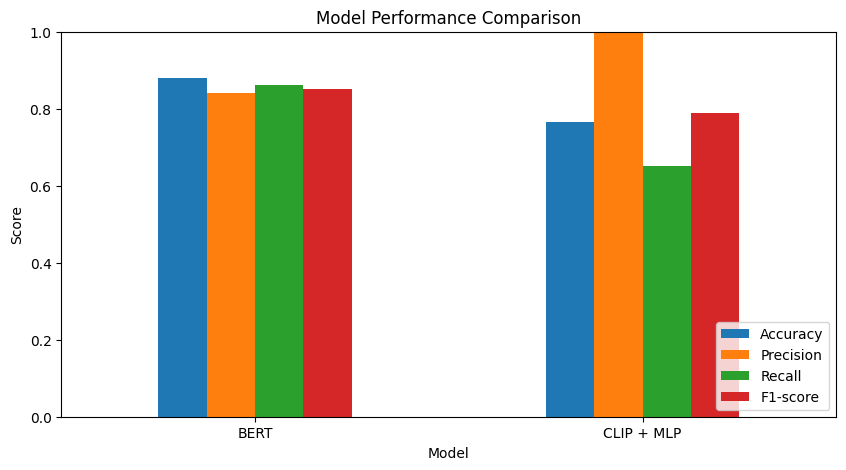

In [ ]:
import matplotlib.pyplot as plt

results_df.set_index("Model")[["Accuracy", "Precision", "Recall", "F1-score"]].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.show()

ViLT Model

In [ ]:
from transformers import ViltProcessor, ViltForImagesAndTextClassification

In [ ]:
from transformers import ViltProcessor

vilt_processor = ViltProcessor.from_pretrained("dandelin/vilt-b32-mlm")


preprocessor_config.json:   0%|          | 0.00/251 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/653 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/320 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [ ]:
from transformers import ViltModel
import torch.nn as nn

vilt_base = ViltModel.from_pretrained("dandelin/vilt-b32-mlm")


pytorch_model.bin:   0%|          | 0.00/543M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/206 [00:00<?, ?it/s]

[transformers] ViltModel LOAD REPORT from: dandelin/vilt-b32-mlm
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
mlm_score.transform.dense.bias       | UNEXPECTED |  | 
mlm_score.transform.dense.weight     | UNEXPECTED |  | 
mlm_score.decoder.weight             | UNEXPECTED |  | 
mlm_score.transform.LayerNorm.weight | UNEXPECTED |  | 
mlm_score.bias                       | UNEXPECTED |  | 
mlm_score.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
#Create ViLT Classifier
class ViLTFakeNewsClassifier(nn.Module):
    def __init__(self, vilt_base):
        super(ViLTFakeNewsClassifier, self).__init__()

        self.vilt = vilt_base

        self.classifier = nn.Sequential(
            nn.Linear(768, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 2)
        )

    def forward(self, input_ids, attention_mask, token_type_ids, pixel_values, pixel_mask):
        outputs = self.vilt(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
            pixel_values=pixel_values,
            pixel_mask=pixel_mask
        )

        cls_output = outputs.pooler_output
        logits = self.classifier(cls_output)

        return logits

In [ ]:
#Create Model
vilt_model = ViLTFakeNewsClassifier(vilt_base)
vilt_model = vilt_model.to(device)

In [ ]:
#Optimizer and Loss
from torch.optim import AdamW

vilt_optimizer = AdamW(vilt_model.parameters(), lr=2e-5)

criterion = nn.CrossEntropyLoss()

In [ ]:
# Create ViLT Dataset
class FakedditViLTDataset(torch.utils.data.Dataset):
    def __init__(self, dataframe, processor):
        self.dataframe = dataframe.reset_index(drop=True)
        self.processor = processor

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]

        text = row["text"]
        image_url = row["image"]
        label = int(row["label"])

        image = load_image(image_url)

        # Adjust max_length to match the model's max_position_embeddings (which is 40)
        encoding = self.processor(
            image,
            text,
            return_tensors="pt",
            padding="max_length",
            truncation=True,
            max_length=40 # Changed from 128 to 40 to match model's expected input size
        )

        item = {key: value.squeeze(0) for key, value in encoding.items()}
        item["labels"] = torch.tensor(label, dtype=torch.long)

        return item

In [ ]:
from PIL import Image
from io import BytesIO
import requests
import time

def load_image(image_url):
    try:
        response = requests.get(
            image_url,
            timeout=10,
            headers={"User-Agent": "Mozilla/5.0"}
        )

        if response.status_code == 429:
            print("Too many requests. Waiting...")
            time.sleep(5)

            response = requests.get(
                image_url,
                timeout=10,
                headers={"User-Agent": "Mozilla/5.0"}
            )

        response.raise_for_status()

        image = Image.open(BytesIO(response.content)).convert("RGB")
        image = image.resize((384, 384))

        return image

    except Exception as e:
        print("Image failed:", image_url)
        print("Error:", e)

        return Image.new("RGB", (384, 384), color="white")

In [ ]:
small_train_df = train_df.sample(100, random_state=42)
small_test_df = test_df.sample(30, random_state=42)

In [ ]:
vilt_train_dataset = FakedditViLTDataset(small_train_df, vilt_processor)
vilt_test_dataset = FakedditViLTDataset(small_test_df, vilt_processor)

In [ ]:
vilt_train_dataset = FakedditViLTDataset(small_train_df, vilt_processor)
vilt_test_dataset = FakedditViLTDataset(small_test_df, vilt_processor)

In [ ]:
vilt_train_loader = DataLoader(
    vilt_train_dataset,
    batch_size=4,
    shuffle=True
)

vilt_test_loader = DataLoader(
    vilt_test_dataset,
    batch_size=4,
    shuffle=False
)

In [ ]:
vilt_train_loader = DataLoader(
    vilt_train_dataset,
    batch_size=4,
    shuffle=True
)

vilt_test_loader = DataLoader(
    vilt_test_dataset,
    batch_size=4,
    shuffle=False
)

In [ ]:
#Test on one match
batch = next(iter(vilt_train_loader))

for key, value in batch.items():
    print(key, value.shape)

model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

input_ids torch.Size([4, 40])
token_type_ids torch.Size([4, 40])
attention_mask torch.Size([4, 40])
pixel_values torch.Size([4, 3, 384, 384])
pixel_mask torch.Size([4, 384, 384])
labels torch.Size([4])


Train ViLT

In [ ]:
from torch.optim import AdamW

vilt_optimizer = AdamW(
    vilt_model.parameters(),
    lr=2e-5
)

In [ ]:
#Training Loops
epochs = 3

for epoch in range(epochs):
    print(f"Epoch {epoch + 1}/{epochs}")

    vilt_model.train()
    total_loss = 0

    progress_bar = tqdm(vilt_train_loader)

    for batch in progress_bar:
        vilt_optimizer.zero_grad()

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        token_type_ids = batch["token_type_ids"].to(device)
        pixel_values = batch["pixel_values"].to(device)
        pixel_mask = batch["pixel_mask"].to(device)
        labels = batch["labels"].to(device)

        logits = vilt_model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
            pixel_values=pixel_values,
            pixel_mask=pixel_mask
        )

        loss = criterion(logits, labels)

        loss.backward()
        vilt_optimizer.step()

        total_loss += loss.item()
        progress_bar.set_postfix({"loss": loss.item()})

    avg_loss = total_loss / len(vilt_train_loader)
    print("Average training loss:", avg_loss)

Epoch 1/3


  0%|          | 0/25 [00:00<?, ?it/s]

Image failed: https://preview.redd.it/rp8s0q5p7fj31.png?width=320&crop=smart&auto=webp&s=9dc45fab59814cc70c3d4f46b367f43bcd67aed3
Error: 404 Client Error: Not Found for url: https://preview.redd.it/rp8s0q5p7fj31.png?width=320&crop=smart&auto=webp&s=9dc45fab59814cc70c3d4f46b367f43bcd67aed3
Image failed: https://preview.redd.it/fm62k2zamzq21.jpg?width=320&crop=smart&auto=webp&s=7647c2e41469637eab1b0ea973d9718e02c8d1d7
Error: 404 Client Error: Not Found for url: https://preview.redd.it/fm62k2zamzq21.jpg?width=320&crop=smart&auto=webp&s=7647c2e41469637eab1b0ea973d9718e02c8d1d7
Image failed: https://preview.redd.it/v635ggi7dzk21.jpg?width=320&crop=smart&auto=webp&s=c7d99c2ef345155e050d4b6c768ab59f54899e32
Error: 404 Client Error: Not Found for url: https://preview.redd.it/v635ggi7dzk21.jpg?width=320&crop=smart&auto=webp&s=c7d99c2ef345155e050d4b6c768ab59f54899e32
Image failed: https://preview.redd.it/ftev4x5ppht21.jpg?width=320&crop=smart&auto=webp&s=99f982f52bc6866b2b21224baf22d8abcfd18976


  0%|          | 0/25 [00:00<?, ?it/s]

Image failed: https://preview.redd.it/v635ggi7dzk21.jpg?width=320&crop=smart&auto=webp&s=c7d99c2ef345155e050d4b6c768ab59f54899e32
Error: 404 Client Error: Not Found for url: https://preview.redd.it/v635ggi7dzk21.jpg?width=320&crop=smart&auto=webp&s=c7d99c2ef345155e050d4b6c768ab59f54899e32
Image failed: https://preview.redd.it/rp8s0q5p7fj31.png?width=320&crop=smart&auto=webp&s=9dc45fab59814cc70c3d4f46b367f43bcd67aed3
Error: 404 Client Error: Not Found for url: https://preview.redd.it/rp8s0q5p7fj31.png?width=320&crop=smart&auto=webp&s=9dc45fab59814cc70c3d4f46b367f43bcd67aed3
Image failed: https://preview.redd.it/ftev4x5ppht21.jpg?width=320&crop=smart&auto=webp&s=99f982f52bc6866b2b21224baf22d8abcfd18976
Error: 404 Client Error: Not Found for url: https://preview.redd.it/ftev4x5ppht21.jpg?width=320&crop=smart&auto=webp&s=99f982f52bc6866b2b21224baf22d8abcfd18976
Image failed: https://preview.redd.it/fm62k2zamzq21.jpg?width=320&crop=smart&auto=webp&s=7647c2e41469637eab1b0ea973d9718e02c8d1d7


  0%|          | 0/25 [00:00<?, ?it/s]

Image failed: https://preview.redd.it/v635ggi7dzk21.jpg?width=320&crop=smart&auto=webp&s=c7d99c2ef345155e050d4b6c768ab59f54899e32
Error: 404 Client Error: Not Found for url: https://preview.redd.it/v635ggi7dzk21.jpg?width=320&crop=smart&auto=webp&s=c7d99c2ef345155e050d4b6c768ab59f54899e32
Image failed: https://preview.redd.it/rp8s0q5p7fj31.png?width=320&crop=smart&auto=webp&s=9dc45fab59814cc70c3d4f46b367f43bcd67aed3
Error: 404 Client Error: Not Found for url: https://preview.redd.it/rp8s0q5p7fj31.png?width=320&crop=smart&auto=webp&s=9dc45fab59814cc70c3d4f46b367f43bcd67aed3
Image failed: https://preview.redd.it/ftev4x5ppht21.jpg?width=320&crop=smart&auto=webp&s=99f982f52bc6866b2b21224baf22d8abcfd18976
Error: 404 Client Error: Not Found for url: https://preview.redd.it/ftev4x5ppht21.jpg?width=320&crop=smart&auto=webp&s=99f982f52bc6866b2b21224baf22d8abcfd18976
Image failed: https://preview.redd.it/fm62k2zamzq21.jpg?width=320&crop=smart&auto=webp&s=7647c2e41469637eab1b0ea973d9718e02c8d1d7


In [ ]:
from tqdm.auto import tqdm
from torch.optim import AdamW
import torch.nn as nn

criterion = nn.CrossEntropyLoss()

vilt_optimizer = AdamW(
    vilt_model.parameters(),
    lr=2e-5
)

epochs = 3

In [ ]:
for epoch in range(epochs):
    print(f"Epoch {epoch + 1}/{epochs}")

    vilt_model.train()
    total_loss = 0

    progress_bar = tqdm(vilt_train_loader)

    for batch in progress_bar:
        vilt_optimizer.zero_grad()

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        token_type_ids = batch["token_type_ids"].to(device)
        pixel_values = batch["pixel_values"].to(device)
        pixel_mask = batch["pixel_mask"].to(device)
        labels = batch["labels"].to(device)

        logits = vilt_model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
            pixel_values=pixel_values,
            pixel_mask=pixel_mask
        )

        loss = criterion(logits, labels)

        loss.backward()
        vilt_optimizer.step()

        total_loss += loss.item()

        progress_bar.set_postfix({"loss": loss.item()})

    avg_loss = total_loss / len(vilt_train_loader)
    print("Average training loss:", avg_loss)

Epoch 1/3


  0%|          | 0/25 [00:00<?, ?it/s]

Image failed: https://preview.redd.it/v635ggi7dzk21.jpg?width=320&crop=smart&auto=webp&s=c7d99c2ef345155e050d4b6c768ab59f54899e32
Error: 404 Client Error: Not Found for url: https://preview.redd.it/v635ggi7dzk21.jpg?width=320&crop=smart&auto=webp&s=c7d99c2ef345155e050d4b6c768ab59f54899e32
Image failed: https://preview.redd.it/fm62k2zamzq21.jpg?width=320&crop=smart&auto=webp&s=7647c2e41469637eab1b0ea973d9718e02c8d1d7
Error: 404 Client Error: Not Found for url: https://preview.redd.it/fm62k2zamzq21.jpg?width=320&crop=smart&auto=webp&s=7647c2e41469637eab1b0ea973d9718e02c8d1d7
Image failed: https://preview.redd.it/rp8s0q5p7fj31.png?width=320&crop=smart&auto=webp&s=9dc45fab59814cc70c3d4f46b367f43bcd67aed3
Error: 404 Client Error: Not Found for url: https://preview.redd.it/rp8s0q5p7fj31.png?width=320&crop=smart&auto=webp&s=9dc45fab59814cc70c3d4f46b367f43bcd67aed3
Image failed: https://preview.redd.it/ftev4x5ppht21.jpg?width=320&crop=smart&auto=webp&s=99f982f52bc6866b2b21224baf22d8abcfd18976


  0%|          | 0/25 [00:00<?, ?it/s]

Image failed: https://preview.redd.it/ftev4x5ppht21.jpg?width=320&crop=smart&auto=webp&s=99f982f52bc6866b2b21224baf22d8abcfd18976
Error: 404 Client Error: Not Found for url: https://preview.redd.it/ftev4x5ppht21.jpg?width=320&crop=smart&auto=webp&s=99f982f52bc6866b2b21224baf22d8abcfd18976
Image failed: https://preview.redd.it/v635ggi7dzk21.jpg?width=320&crop=smart&auto=webp&s=c7d99c2ef345155e050d4b6c768ab59f54899e32
Error: 404 Client Error: Not Found for url: https://preview.redd.it/v635ggi7dzk21.jpg?width=320&crop=smart&auto=webp&s=c7d99c2ef345155e050d4b6c768ab59f54899e32
Image failed: https://preview.redd.it/fm62k2zamzq21.jpg?width=320&crop=smart&auto=webp&s=7647c2e41469637eab1b0ea973d9718e02c8d1d7
Error: 404 Client Error: Not Found for url: https://preview.redd.it/fm62k2zamzq21.jpg?width=320&crop=smart&auto=webp&s=7647c2e41469637eab1b0ea973d9718e02c8d1d7
Image failed: https://preview.redd.it/rp8s0q5p7fj31.png?width=320&crop=smart&auto=webp&s=9dc45fab59814cc70c3d4f46b367f43bcd67aed3


  0%|          | 0/25 [00:00<?, ?it/s]

Image failed: https://preview.redd.it/v635ggi7dzk21.jpg?width=320&crop=smart&auto=webp&s=c7d99c2ef345155e050d4b6c768ab59f54899e32
Error: 404 Client Error: Not Found for url: https://preview.redd.it/v635ggi7dzk21.jpg?width=320&crop=smart&auto=webp&s=c7d99c2ef345155e050d4b6c768ab59f54899e32
Image failed: https://preview.redd.it/fm62k2zamzq21.jpg?width=320&crop=smart&auto=webp&s=7647c2e41469637eab1b0ea973d9718e02c8d1d7
Error: 404 Client Error: Not Found for url: https://preview.redd.it/fm62k2zamzq21.jpg?width=320&crop=smart&auto=webp&s=7647c2e41469637eab1b0ea973d9718e02c8d1d7
Image failed: https://preview.redd.it/ftev4x5ppht21.jpg?width=320&crop=smart&auto=webp&s=99f982f52bc6866b2b21224baf22d8abcfd18976
Error: 404 Client Error: Not Found for url: https://preview.redd.it/ftev4x5ppht21.jpg?width=320&crop=smart&auto=webp&s=99f982f52bc6866b2b21224baf22d8abcfd18976
Image failed: https://preview.redd.it/rp8s0q5p7fj31.png?width=320&crop=smart&auto=webp&s=9dc45fab59814cc70c3d4f46b367f43bcd67aed3


Evaluate ViLT

In [ ]:
vilt_model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():
    for batch in tqdm(vilt_test_loader):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        token_type_ids = batch["token_type_ids"].to(device)
        pixel_values = batch["pixel_values"].to(device)
        pixel_mask = batch["pixel_mask"].to(device)
        labels = batch["labels"].to(device)

        logits = vilt_model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
            pixel_values=pixel_values,
            pixel_mask=pixel_mask
        )

        predictions = torch.argmax(logits, dim=1)

        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

  0%|          | 0/8 [00:00<?, ?it/s]

Image failed: https://preview.redd.it/2822ih7oxgo11.jpg?width=320&crop=smart&auto=webp&s=d874a16481e9b6b7c35096ecd83766aa1e71f44e
Error: 404 Client Error: Not Found for url: https://preview.redd.it/2822ih7oxgo11.jpg?width=320&crop=smart&auto=webp&s=d874a16481e9b6b7c35096ecd83766aa1e71f44e
Image failed: https://preview.redd.it/365l10xmxmk31.jpg?width=320&crop=smart&auto=webp&s=e07ac24e9883e34890c9621689166b7de7ff6ee8
Error: 404 Client Error: Not Found for url: https://preview.redd.it/365l10xmxmk31.jpg?width=320&crop=smart&auto=webp&s=e07ac24e9883e34890c9621689166b7de7ff6ee8
Image failed: https://preview.redd.it/o4yamdfk1fd31.jpg?width=320&crop=smart&auto=webp&s=618b791b3465333a942c4145f22f63d06fb24441
Error: 404 Client Error: Not Found for url: https://preview.redd.it/o4yamdfk1fd31.jpg?width=320&crop=smart&auto=webp&s=618b791b3465333a942c4145f22f63d06fb24441
Image failed: https://external-preview.redd.it/sa2i1FyyMCtmdTNkBrOgqYWGWeMKvz8zNUz-tRhHxPk.jpg?width=320&crop=smart&auto=webp&s=3c

In [ ]:
vilt_accuracy = accuracy_score(all_labels, all_predictions)

vilt_precision, vilt_recall, vilt_f1, _ = precision_recall_fscore_support(
    all_labels,
    all_predictions,
    average="binary",
    zero_division=0
)

print("ViLT Accuracy:", vilt_accuracy)
print("ViLT Precision:", vilt_precision)
print("ViLT Recall:", vilt_recall)
print("ViLT F1-score:", vilt_f1)

ViLT Accuracy: 0.5
ViLT Precision: 0.8571428571428571
ViLT Recall: 0.3
ViLT F1-score: 0.4444444444444444


In [ ]:
print(classification_report(
    all_labels,
    all_predictions,
    target_names=["real", "fake"],
    zero_division=0
))

              precision    recall  f1-score   support

        real       0.39      0.90      0.55        10
        fake       0.86      0.30      0.44        20

    accuracy                           0.50        30
   macro avg       0.62      0.60      0.49        30
weighted avg       0.70      0.50      0.48        30



In [ ]:
print(confusion_matrix(all_labels, all_predictions))

[[ 9  1]
 [14  6]]


In [ ]:
results = [
    {
        "Model": "BERT",
        "Modality": "Text only",
        "Accuracy":0.881083381017357,
        "Precision": 0.8404383122792967,
        "Recall": 0.8611608475082065,
        "F1-score": 0.8506733975717155
    },
    {
        "Model": "CLIP + MLP",
        "Modality": "Text + Image",
        "Accuracy": 0.7667,
        "Precision": 1.0000,
        "Recall": 0.6500,
        "F1-score": 0.7879
    },
    {
        "Model": "ViLT",
        "Modality": "Text + Image",
        "Accuracy": vilt_accuracy,
        "Precision": vilt_precision,
        "Recall": vilt_recall,
        "F1-score": vilt_f1
    }
]

results_df = pd.DataFrame(results)

results_df

,Model,Modality,Accuracy,Precision,Recall,F1-score
0,BERT,Text only,0.881083,0.840438,0.861161,0.850673
1,CLIP + MLP,Text + Image,0.766700,1.000000,0.650000,0.787900
2,ViLT,Text + Image,0.500000,0.857143,0.300000,0.444444


In [ ]:
results_df.to_csv("/content/model_comparison_results.csv", index=False)

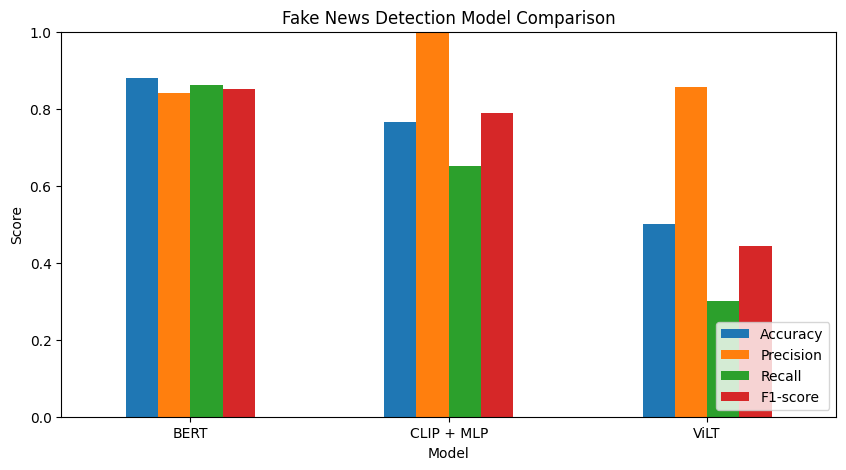

In [ ]:
import matplotlib.pyplot as plt

results_df.set_index("Model")[["Accuracy", "Precision", "Recall", "F1-score"]].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Fake News Detection Model Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.show()

Save ViLT Model

In [ ]:
vilt_save_path = "/content/vilt_fake_news_classifier.pth"

torch.save(vilt_model.state_dict(), vilt_save_path)

print("ViLT model saved to:", vilt_save_path)

ViLT model saved to: /content/vilt_fake_news_classifier.pth


In [ ]:
files.download(vilt_save_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
vilt_processor.save_pretrained("/content/vilt_processor")

['/content/vilt_processor/processor_config.json']

In [ ]:
!zip -r vilt_processor.zip vilt_processor

  adding: vilt_processor/ (stored 0%)
  adding: vilt_processor/tokenizer.json (deflated 71%)
  adding: vilt_processor/processor_config.json (deflated 56%)
  adding: vilt_processor/tokenizer_config.json (deflated 45%)


In [ ]:
files.download("/content/vilt_processor.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Add explainability

In [ ]:
#Create Prediction function for CLIP
def predict_clip(text, image_url):
    model.eval()

    image = load_image(image_url)
    text = clean_text(text)

    inputs = clip_processor(
        text=[text],
        images=image,
        return_tensors="pt",
        padding=True,
        truncation=True
    )

    inputs = {key: value.to(device) for key, value in inputs.items()}

    with torch.no_grad():
        logits = model(
            input_ids=inputs["input_ids"],
            attention_mask=inputs["attention_mask"],
            pixel_values=inputs["pixel_values"]
        )

        probabilities = torch.softmax(logits, dim=1)
        prediction = torch.argmax(probabilities, dim=1).item()

    label = "Fake" if prediction == 1 else "Real"
    confidence = probabilities[0][prediction].item()

    return label, confidence

In [ ]:
#Explanation Function
def generate_basic_explanation(label, confidence):
    confidence_percent = confidence * 100

    if label == "Fake":
        explanation = (
            f"The model predicts this post as fake with {confidence_percent:.2f}% confidence. "
            "This decision is based on the combined text and image features learned by the multimodal model. "
            "The text-image combination may contain misleading, exaggerated, or inconsistent signals."
        )
    else:
        explanation = (
            f"The model predicts this post as real with {confidence_percent:.2f}% confidence. "
            "This decision is based on the combined text and image features learned by the multimodal model. "
            "The text and image appear more consistent with patterns learned from real news samples."
        )

    return explanation

Text: my walgreens offbrand mucinex was engraved with the letters mucinex but in a different order
Prediction: Fake
Confidence: 0.5547280311584473
Explanation: The model predicts this post as fake with 55.47% confidence. This decision is based on the combined text and image features learned by the multimodal model. The text-image combination may contain misleading, exaggerated, or inconsistent signals.


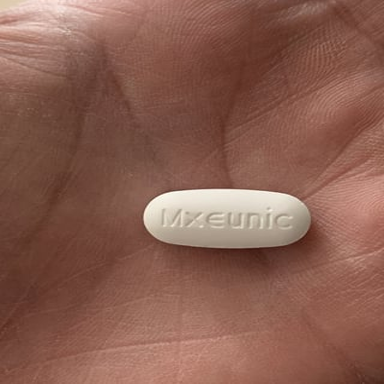

In [ ]:
#Test on one sample
sample = multi_df.iloc[0]

text = sample["text"]
image_url = sample["image"]

label, confidence = predict_clip(text, image_url)
explanation = generate_basic_explanation(label, confidence)

print("Text:", text)
print("Prediction:", label)
print("Confidence:", confidence)
print("Explanation:", explanation)

display(load_image(image_url))

BLIP Model

In [ ]:
from transformers import BlipProcessor, BlipForConditionalGeneration

In [ ]:
#Load BLIP Caption Model
blip_processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")

blip_model = BlipForConditionalGeneration.from_pretrained(
    "Salesforce/blip-image-captioning-base"
)

blip_model = blip_model.to(device)
blip_model.eval()

preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.56k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

BlipForConditionalGeneration(
  (vision_model): BlipVisionModel(
    (embeddings): BlipVisionEmbeddings(
      (patch_embedding): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    )
    (encoder): BlipEncoder(
      (layers): ModuleList(
        (0-11): 12 x BlipEncoderLayer(
          (self_attn): BlipAttention(
            (dropout): Dropout(p=0.0, inplace=False)
            (qkv): Linear(in_features=768, out_features=2304, bias=True)
            (projection): Linear(in_features=768, out_features=768, bias=True)
          )
          (layer_norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (mlp): BlipMLP(
            (activation_fn): GELUActivation()
            (fc1): Linear(in_features=768, out_features=3072, bias=True)
            (fc2): Linear(in_features=3072, out_features=768, bias=True)
          )
          (layer_norm2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        )
      )
    )
    (post_layernorm): LayerNorm((768,), eps=1e-0

In [ ]:
#Generate image caption
def generate_image_caption(image_url):
    image = load_image(image_url)

    inputs = blip_processor(
        image,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        output = blip_model.generate(
            **inputs,
            max_new_tokens=50
        )

    caption = blip_processor.decode(output[0], skip_special_tokens=True)

    return caption

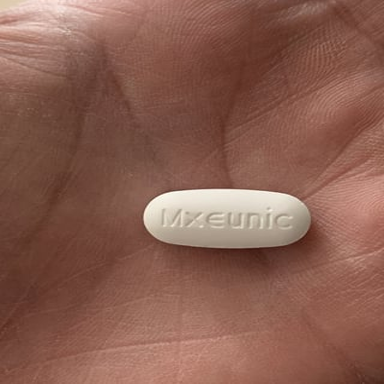

Generated caption: a pill pill in someone ' s hand


In [ ]:
#Test Caption
sample = multi_df.iloc[0]

image_url = sample["image"]
caption = generate_image_caption(image_url)

display(load_image(image_url))
print("Generated caption:", caption)

In [ ]:
#Combine Prediction + Explanation
def generate_multimodal_explanation(text, image_url):
    prediction, confidence = predict_clip(text, image_url)
    caption = generate_image_caption(image_url)

    explanation = (
        f"The model predicts this post as {prediction} with {confidence * 100:.2f}% confidence. "
        f"The image appears to show: '{caption}'. "
        f"The decision is based on both the news text and the visual content."
    )

    return prediction, confidence, caption, explanation

Text: my walgreens offbrand mucinex was engraved with the letters mucinex but in a different order
Prediction: Fake
Confidence: 0.5547280311584473
Image caption: a pill pill in someone ' s hand
Explanation: The model predicts this post as Fake with 55.47% confidence. The image appears to show: 'a pill pill in someone ' s hand'. The decision is based on both the news text and the visual content.


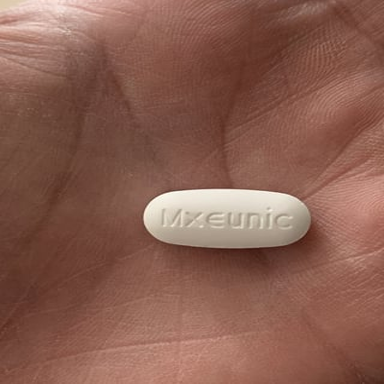

In [ ]:
#Test Full Explainable Output
sample = multi_df.iloc[0]

text = sample["text"]
image_url = sample["image"]

prediction, confidence, caption, explanation = generate_multimodal_explanation(text, image_url)

print("Text:", text)
print("Prediction:", prediction)
print("Confidence:", confidence)
print("Image caption:", caption)
print("Explanation:", explanation)

display(load_image(image_url))

In [ ]:
#Simple Text-Image Consistency Function
def generate_consistency_explanation(text, caption, prediction, confidence):
    text_lower = text.lower()
    caption_lower = caption.lower()

    text_words = set(text_lower.split())
    caption_words = set(caption_lower.split())

    common_words = text_words.intersection(caption_words)

    confidence_percent = confidence * 100

    if len(common_words) >= 2:
        consistency = "The text and image appear to share some related words or concepts."
    else:
        consistency = "The text and image appear to have limited obvious overlap."

    if prediction == "Fake":
        explanation = (
            f"The model predicts this post as Fake with {confidence_percent:.2f}% confidence. "
            f"The generated image caption is: '{caption}'. "
            f"{consistency} This may indicate that the post contains misleading or weakly supported multimodal information."
        )
    else:
        explanation = (
            f"The model predicts this post as Real with {confidence_percent:.2f}% confidence. "
            f"The generated image caption is: '{caption}'. "
            f"{consistency} This suggests that the visual content may be more consistent with the text."
        )

    return explanation

In [ ]:
#Update Full Explanation Function
def generate_multimodal_explanation(text, image_url):
    prediction, confidence = predict_clip(text, image_url)
    caption = generate_image_caption(image_url)

    explanation = generate_consistency_explanation(
        text=text,
        caption=caption,
        prediction=prediction,
        confidence=confidence
    )

    return prediction, confidence, caption, explanation

Text: hackers leak emails from uae ambassador to us
Prediction: Fake
Confidence: 0.6286904811859131
Caption: a man in a suit sitting at a table
Explanation: The model predicts this post as Fake with 62.87% confidence. The generated image caption is: 'a man in a suit sitting at a table'. The text and image appear to have limited obvious overlap. This may indicate that the post contains misleading or weakly supported multimodal information.


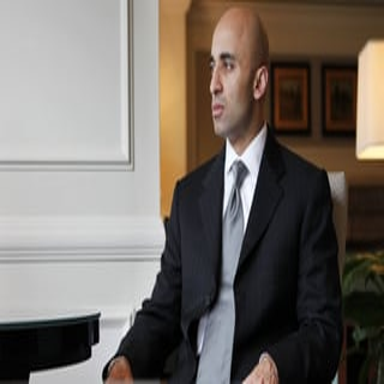

In [ ]:
#Test
sample = multi_df.iloc[2]

text = sample["text"]
image_url = sample["image"]

prediction, confidence, caption, explanation = generate_multimodal_explanation(text, image_url)

print("Text:", text)
print("Prediction:", prediction)
print("Confidence:", confidence)
print("Caption:", caption)
print("Explanation:", explanation)

display(load_image(image_url))

Function that gives neat output

In [ ]:
from IPython.display import display

In [ ]:
def explain_fake_news_sample(text, image_url):
    prediction, confidence, caption, explanation = generate_multimodal_explanation(
        text,
        image_url
    )

    image = load_image(image_url)

    print("=" * 60)
    print("FAKE NEWS DETECTION RESULT")
    print("=" * 60)

    print("\nText:")
    print(text)

    print("\nPrediction:")
    print(prediction)

    print("\nConfidence:")
    print(f"{confidence * 100:.2f}%")

    print("\nGenerated Image Caption:")
    print(caption)

    print("\nExplanation:")
    print(explanation)

    print("\nImage:")
    display(image)

FAKE NEWS DETECTION RESULT

Text:
my walgreens offbrand mucinex was engraved with the letters mucinex but in a different order

Prediction:
Fake

Confidence:
55.47%

Generated Image Caption:
a pill pill in someone ' s hand

Explanation:
The model predicts this post as Fake with 55.47% confidence. The generated image caption is: 'a pill pill in someone ' s hand'. The text and image appear to share some related words or concepts. This may indicate that the post contains misleading or weakly supported multimodal information.

Image:


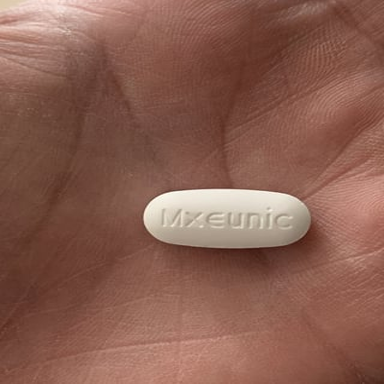

In [ ]:
#Test it
sample = multi_df.iloc[0]

explain_fake_news_sample(
    sample["text"],
    sample["image"]
)

FAKE NEWS DETECTION RESULT

Text:
victory the great european crusade  vichy france

Prediction:
Real

Confidence:
54.61%

Generated Image Caption:
a poster advertising a movie

Explanation:
The model predicts this post as Real with 54.61% confidence. The generated image caption is: 'a poster advertising a movie'. The text and image appear to have limited obvious overlap. This suggests that the visual content may be more consistent with the text.

Image:


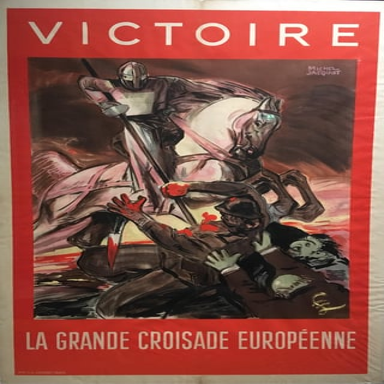

In [ ]:
sample = multi_df.iloc[10]

explain_fake_news_sample(
    sample["text"],
    sample["image"]
)

FAKE NEWS DETECTION RESULT

Text:
quit horsing around

Prediction:
Real

Confidence:
50.76%

Generated Image Caption:
a man riding a horse in a yard

Explanation:
The model predicts this post as Real with 50.76% confidence. The generated image caption is: 'a man riding a horse in a yard'. The text and image appear to have limited obvious overlap. This suggests that the visual content may be more consistent with the text.

Image:


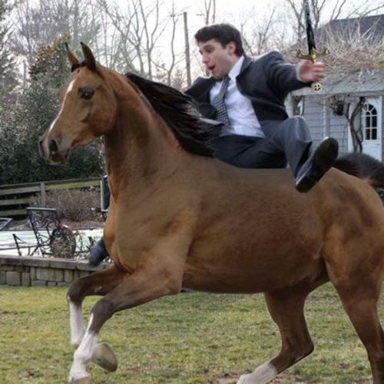

In [ ]:
sample = multi_df.iloc[50]

explain_fake_news_sample(
    sample["text"],
    sample["image"]
)

Multiple sample test

In [ ]:
explanation_samples = multi_df.sample(10, random_state=42)

In [ ]:
explanation_results = []

for index, row in explanation_samples.iterrows():
    text = row["text"]
    image_url = row["image"]
    true_label = row["label"]

    prediction, confidence, caption, explanation = generate_multimodal_explanation(
        text,
        image_url
    )

    explanation_results.append({
        "text": text,
        "image": image_url,
        "true_label": true_label,
        "prediction": prediction,
        "confidence": confidence,
        "caption": caption,
        "explanation": explanation
    })

In [ ]:
explanations_df = pd.DataFrame(explanation_results)

explanations_df.head()

,text,image,true_label,prediction,confidence,caption,explanation
0,a terrifying and chocolatey cookie monster,https://external-preview.redd.it/X7DmH0mogUIdN...,0,Real,0.503780,a bowl filled with chocolate covered in chocolate,The model predicts this post as Real with 50.3...
1,the synagogue cared for by muslims bbc reel,https://external-preview.redd.it/zfsZb2rkBp7yD...,1,Fake,0.514821,a clock on a building,The model predicts this post as Fake with 51.4...
2,the flight of this plane,https://external-preview.redd.it/Uxv3iPx_ks420...,1,Real,0.500503,a kite flying in the sky over a city,The model predicts this post as Real with 50.0...
3,mr butterface and his little brother,https://external-preview.redd.it/CRkMU3Tz54y_l...,0,Real,0.502966,a black stove,The model predicts this post as Real with 50.3...
4,this pylon looks like a sleeping owl,https://external-preview.redd.it/Bpu1iKCH7zeSv...,0,Fake,0.641329,a field with power lines and a large cloud,The model predicts this post as Fake with 64.1...


In [ ]:
explanations_df.to_csv("/content/explainable_fake_news_outputs.csv", index=False)

In [ ]:
from google.colab import files

files.download("/content/explainable_fake_news_outputs.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Comparison

In [ ]:
results = [
    {
        "Model": "BERT",
        "Input": "Text",
        "Accuracy":0.881083381017357,
        "Precision":  0.8404383122792967,
        "Recall": 0.8611608475082065,
        "F1-score": 0.8506733975717155
    },
    {
        "Model": "CLIP + MLP",
        "Input": "Text + Image",
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1
    },
    {
        "Model": "ViLT",
        "Input": "Text + Image",
        "Accuracy": vilt_accuracy,
        "Precision": vilt_precision,
        "Recall": vilt_recall,
        "F1-score": vilt_f1
    }
]

results_df = pd.DataFrame(results)
results_df

,Model,Input,Accuracy,Precision,Recall,F1-score
0,BERT,Text,0.881083,0.840438,0.861161,0.850673
1,CLIP + MLP,Text + Image,0.712121,0.666667,0.944444,0.781609
2,ViLT,Text + Image,0.500000,0.857143,0.300000,0.444444


In [ ]:
best_model = results_df.sort_values("F1-score", ascending=False).iloc[0]

best_model

,0
Model,BERT
Input,Text
Accuracy,0.881083
Precision,0.840438
Recall,0.861161
F1-score,0.850673


BLIP based Classifier

In [ ]:
#Generate caption for dataset
caption_df = multi_df.sample(100, random_state=42).copy()

In [ ]:
captions = []

for index, row in tqdm(caption_df.iterrows(), total=len(caption_df)):
    image_url = row["image"]

    caption = generate_image_caption(image_url)

    captions.append(caption)

  0%|          | 0/100 [00:00<?, ?it/s]

Image failed: https://preview.redd.it/8sv4cqozr2v01.jpg?width=320&crop=smart&auto=webp&s=5dd1bfb8098586d7ec222e15f3b1e858f9c0ee8b
Error: 404 Client Error: Not Found for url: https://preview.redd.it/8sv4cqozr2v01.jpg?width=320&crop=smart&auto=webp&s=5dd1bfb8098586d7ec222e15f3b1e858f9c0ee8b
Image failed: https://preview.redd.it/4hd6jzxt93p01.jpg?width=320&crop=smart&auto=webp&s=e6f8e74c6750e0891323f4bf090e104c6cdd1da1
Error: 404 Client Error: Not Found for url: https://preview.redd.it/4hd6jzxt93p01.jpg?width=320&crop=smart&auto=webp&s=e6f8e74c6750e0891323f4bf090e104c6cdd1da1
Image failed: https://preview.redd.it/zht1vflprgi21.jpg?width=320&crop=smart&auto=webp&s=9ef3f3d73c1e51f5ea960841db408a5ad168991a
Error: 404 Client Error: Not Found for url: https://preview.redd.it/zht1vflprgi21.jpg?width=320&crop=smart&auto=webp&s=9ef3f3d73c1e51f5ea960841db408a5ad168991a


In [ ]:
caption_df["image_caption"] = captions

caption_df.head()

,text,image,label,image_caption
470473,a terrifying and chocolatey cookie monster,https://external-preview.redd.it/X7DmH0mogUIdN...,0,a bowl filled with chocolate covered in chocolate
188533,the synagogue cared for by muslims bbc reel,https://external-preview.redd.it/zfsZb2rkBp7yD...,1,a clock on a building
270778,the flight of this plane,https://external-preview.redd.it/Uxv3iPx_ks420...,1,a kite flying in the sky over a city
278569,mr butterface and his little brother,https://external-preview.redd.it/CRkMU3Tz54y_l...,0,a black stove
439616,this pylon looks like a sleeping owl,https://external-preview.redd.it/Bpu1iKCH7zeSv...,0,a field with power lines and a large cloud


In [ ]:
#Combine Text+Caption
caption_df["combined_text"] = (
    caption_df["text"].astype(str)
    + " [IMAGE CAPTION] "
    + caption_df["image_caption"].astype(str)
)

caption_df[["text", "image_caption", "combined_text", "label"]].head()

,text,image_caption,combined_text,label
470473,a terrifying and chocolatey cookie monster,a bowl filled with chocolate covered in chocolate,a terrifying and chocolatey cookie monster [IM...,0
188533,the synagogue cared for by muslims bbc reel,a clock on a building,the synagogue cared for by muslims bbc reel [...,1
270778,the flight of this plane,a kite flying in the sky over a city,the flight of this plane [IMAGE CAPTION] a kit...,1
278569,mr butterface and his little brother,a black stove,mr butterface and his little brother [IMAGE CA...,0
439616,this pylon looks like a sleeping owl,a field with power lines and a large cloud,this pylon looks like a sleeping owl [IMAGE CA...,0


In [ ]:
#Train-Test Split
train_caption_df, test_caption_df = train_test_split(
    caption_df,
    test_size=0.2,
    random_state=42,
    stratify=caption_df["label"]
)

In [ ]:
#Tokenize Combined Text
caption_tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [ ]:
train_texts = train_caption_df["combined_text"].tolist()
test_texts = test_caption_df["combined_text"].tolist()

train_labels = train_caption_df["label"].tolist()
test_labels = test_caption_df["label"].tolist()

In [ ]:
train_encodings = caption_tokenizer(
    train_texts,
    padding=True,
    truncation=True,
    max_length=128
)

test_encodings = caption_tokenizer(
    test_texts,
    padding=True,
    truncation=True,
    max_length=128
)

In [ ]:
class FakeNewsDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_caption_dataset = FakeNewsDataset(train_encodings, train_labels)
test_caption_dataset = FakeNewsDataset(test_encodings, test_labels)

In [ ]:
#Train BERT On Text + Caption
from transformers import BertForSequenceClassification

caption_bert_model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)

caption_bert_model = caption_bert_model.to(device)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DataLoader, optimizer, and train BLIP Caption + BERT

In [ ]:
train_caption_loader = DataLoader(
    train_caption_dataset,
    batch_size=8,
    shuffle=True
)

test_caption_loader = DataLoader(
    test_caption_dataset,
    batch_size=8,
    shuffle=False
)

In [ ]:
#Create optimizer
from torch.optim import AdamW

caption_optimizer = AdamW(
    caption_bert_model.parameters(),
    lr=2e-5
)

In [ ]:
caption_df = multi_df.sample(500, random_state=42).copy()

In [ ]:
#Train
epochs = 5

for epoch in range(epochs):
    print(f"Epoch {epoch + 1}/{epochs}")

    caption_bert_model.train()
    total_loss = 0

    progress_bar = tqdm(train_caption_loader)

    for batch in progress_bar:
        caption_optimizer.zero_grad()

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = caption_bert_model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss

        loss.backward()
        caption_optimizer.step()

        total_loss += loss.item()

        progress_bar.set_postfix({"loss": loss.item()})

    avg_loss = total_loss / len(train_caption_loader)
    print("Average training loss:", avg_loss)

Epoch 1/5


  0%|          | 0/10 [00:00<?, ?it/s]

Average training loss: 0.6830537140369415
Epoch 2/5


  0%|          | 0/10 [00:00<?, ?it/s]

Average training loss: 0.5894743621349334
Epoch 3/5


...

Average training loss: 0.39900574684143064
Epoch 4/5


  0%|          | 0/10 [00:00<?, ?it/s]

Average training loss: 0.27397454530000687
Epoch 5/5


  0%|          | 0/10 [00:00<?, ?it/s]

Average training loss: 0.15485868230462074


Evaluate BLIP Caption+BERT

In [ ]:
caption_bert_model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():
    for batch in tqdm(test_caption_loader):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = caption_bert_model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        logits = outputs.logits
        predictions = torch.argmax(logits, dim=1)

        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

  0%|          | 0/3 [00:00<?, ?it/s]

In [ ]:
caption_accuracy = accuracy_score(all_labels, all_predictions)

caption_precision, caption_recall, caption_f1, _ = precision_recall_fscore_support(
    all_labels,
    all_predictions,
    average="binary",
    zero_division=0
)

print("BLIP Caption + BERT Accuracy:", caption_accuracy)
print("BLIP Caption + BERT Precision:", caption_precision)
print("BLIP Caption + BERT Recall:", caption_recall)
print("BLIP Caption + BERT F1-score:", caption_f1)

BLIP Caption + BERT Accuracy: 0.75
BLIP Caption + BERT Precision: 0.8
BLIP Caption + BERT Recall: 0.5
BLIP Caption + BERT F1-score: 0.6153846153846154


In [ ]:
print(train_caption_df["label"].value_counts())
print(test_caption_df["label"].value_counts())

label
0    48
1    32
Name: count, dtype: int64
label
0    12
1     8
Name: count, dtype: int64


In [ ]:
caption_df = multi_df.sample(300, random_state=42).copy()

In [ ]:
print("Predicted labels:", pd.Series(all_predictions).value_counts())
print("True labels:", pd.Series(all_labels).value_counts())

Predicted labels: 0    15
1     5
Name: count, dtype: int64
True labels: 0    12
1     8
Name: count, dtype: int64


Comparison

In [ ]:
results = [
    {
        "Model": "BERT",
        "Modality": "Text only",
       "Accuracy":0.881083381017357,
        "Precision":  0.8404383122792967,
        "Recall": 0.8611608475082065,
        "F1-score": 0.8506733975717155
    },
    {
        "Model": "CLIP + MLP",
        "Modality": "Text + Image",
        "Accuracy": 0.7667,
        "Precision": 1.0000,
        "Recall": 0.6500,
        "F1-score": 0.7879
    },
    {
        "Model": "ViLT",
        "Modality": "Text + Image",
        "Accuracy": vilt_accuracy,
        "Precision": vilt_precision,
        "Recall": vilt_recall,
        "F1-score": vilt_f1
    },
    {
        "Model": "BLIP Caption + BERT",
        "Modality": "Text + Generated image caption",
        "Accuracy": 0.55,
        "Precision": 0.3333,
        "Recall": 0.1250,
        "F1-score": 0.1818
    }
]

results_df = pd.DataFrame(results)
results_df

,Model,Modality,Accuracy,Precision,Recall,F1-score
0,BERT,Text only,0.881083,0.840438,0.861161,0.850673
1,CLIP + MLP,Text + Image,0.766700,1.000000,0.650000,0.787900
2,ViLT,Text + Image,0.500000,0.857143,0.300000,0.444444
3,BLIP Caption + BERT,Text + Generated image caption,0.550000,0.333300,0.125000,0.181800


In [ ]:
best_model = results_df.sort_values("F1-score", ascending=False).iloc[0]

best_model

,0
Model,BERT
Modality,Text only
Accuracy,0.881083
Precision,0.840438
Recall,0.861161
F1-score,0.850673


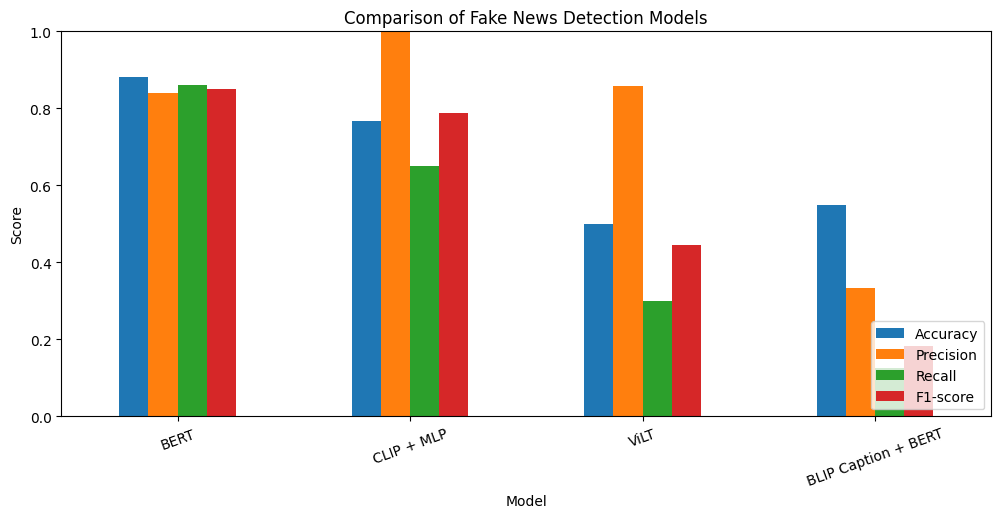

In [ ]:
results_df.set_index("Model")[["Accuracy", "Precision", "Recall", "F1-score"]].plot(
    kind="bar",
    figsize=(12, 5)
)

plt.title("Comparison of Fake News Detection Models")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.legend(loc="lower right")
plt.show()

Error Analysis

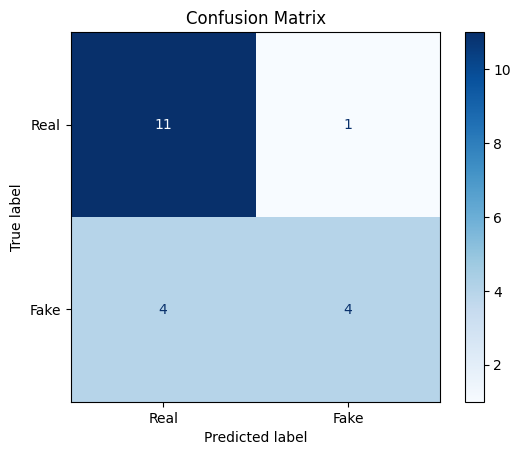

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_predictions)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Real", "Fake"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm # Ensure tqdm is imported for the re-evaluation progress bar

# Re-create small_test_df to ensure it matches the size used for CLIP evaluation (100 samples)
# This is necessary because small_test_df was later overwritten for ViLT evaluation (30 samples)
_, test_df_original = train_test_split(
    multi_df,
    test_size=0.2,
    random_state=42,
    stratify=multi_df["label"]
)
small_test_df = test_df_original.sample(100, random_state=42)

# Ensure small_test_df has the 'text_length' and 'text_type' columns.
# This guards against cases where it might have been created without them.
if "text_length" not in small_test_df.columns:
    print("Adding 'text_length' and 'text_type' to small_test_df...")
    small_test_df["text_length"] = small_test_df["text"].astype(str).apply(lambda x: len(x.split()))
    median_length_for_small_test = small_test_df["text_length"].median()
    small_test_df["text_type"] = small_test_df["text_length"].apply(
        lambda x: "short_text" if x <= median_length_for_small_test else "long_text"
    )

# --- BEGIN MODIFICATION FOR CONSISTENCY CHECK AND RE-EVALUATION ---
# Check if all_original_small_test_df_indices is available and if all_labels is consistent with it.
# If not, it means all_labels and all_predictions were likely overwritten by a subsequent model's evaluation,
# and we need to re-run the CLIP evaluation to get the correct data for this error analysis.

# The variable `all_original_small_test_df_indices` is populated during the CLIP evaluation loop (Cell Pt7xLS69mMob).
# We need to ensure `all_labels` and `all_predictions` are also from that same CLIP evaluation.
# Assuming the current error analysis is intended for the CLIP model.

# A more robust check might be `len(all_labels) != len(all_original_small_test_df_indices)`
# but as `processed_small_test_df` is built from `all_original_small_test_df_indices`, we can use its length.
if 'all_original_small_test_df_indices' not in globals() or \
   len(all_labels) != len(small_test_df.loc[all_original_small_test_df_indices]):
    print("\n--- Inconsistency Detected ---")
    print("The `all_labels` and `all_predictions` variables do not match the expected length for CLIP error analysis.")
    print("This usually happens when subsequent model evaluations (e.g., BLIP, ViLT) overwrite these variables.")
    print("Re-running the CLIP model's evaluation to ensure correct data for this error analysis.")

    # Re-run the CLIP evaluation logic here, as it's the most self-contained way to get fresh, correct data.
    # This block is adapted from cell Pt7xLS69mMob.
    from torch.utils.data import DataLoader
    test_dataset = FakedditCLIPDataset(small_test_df, clip_processor)
    test_loader = DataLoader(
        test_dataset,
        batch_size=4,
        shuffle=False,
        collate_fn=custom_collate_fn
    )

    model.eval() # Ensure CLIP model is in evaluation mode

    all_predictions = []
    all_labels = []
    all_original_small_test_df_indices = [] # Re-initialize for fresh data from CLIP

    with torch.no_grad():
        for batch in tqdm(test_loader, desc="Re-running CLIP evaluation for error analysis"):
            if batch is None: # Handle empty batches from custom_collate_fn
                continue
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            pixel_values = batch["pixel_values"].to(device)
            labels = batch["label"].to(device)
            original_indices = batch["original_idx_from_small_test_df"].to(device)

            logits = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                pixel_values=pixel_values
            )

            predictions = torch.argmax(logits, dim=1)

            all_predictions.extend(predictions.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_original_small_test_df_indices.extend(original_indices.cpu().numpy())
    print("CLIP evaluation re-run completed. Variables `all_labels`, `all_predictions`, and `all_original_small_test_df_indices` are now consistent.\n")
# --- END MODIFICATION ---


# Use the collected all_original_small_test_df_indices to get the relevant rows and text_type
# from small_test_df. These indices are from the original small_test_df, so .loc works correctly.
# Ensure all_original_small_test_df_indices is available from the evaluation loop.
if 'all_original_small_test_df_indices' not in globals(): # Re-check if somehow still missing (unlikely after re-run)
    raise NameError("all_original_small_test_df_indices not found. Please ensure the CLIP evaluation loop (cell Pt7xLS69mMob) has run successfully.")

# Filter small_test_df to include only the samples that were actually processed
# and for which we have predictions.
processed_small_test_df = small_test_df.loc[all_original_small_test_df_indices].copy()

# Now, create error_df with true_label, predicted_label, and the filtered text_types
# Ensure lengths match before creating the DataFrame
if len(all_labels) == len(all_predictions) and len(all_labels) == len(processed_small_test_df):
    error_df = processed_small_test_df.copy()
    error_df["true_label"] = all_labels
    error_df["predicted_label"] = all_predictions
else:
    # This else block should ideally not be reached after the re-evaluation logic above.
    print(f"Length mismatch detected (after re-evaluation attempt):")
    print(f"  len(all_labels): {len(all_labels)}")
    print(f"  len(all_predictions): {len(all_predictions)}")
    print(f"  len(processed_small_test_df): {len(processed_small_test_df)}")
    raise ValueError("Cannot create error_df due to length mismatch even after ensuring consistency. Please check the evaluation setup.")

# Add true_name and predicted_name as before
error_df["true_name"] = error_df["true_label"].map({
    0: "Real",
    1: "Fake"
})

error_df["predicted_name"] = error_df["predicted_label"].map({
    0: "Real",
    1: "Fake"
})

print(f"error_df columns after creation: {error_df.columns.tolist()}")
print(f"First 5 rows of error_df:\n{error_df.head()}")

Adding 'text_length' and 'text_type' to small_test_df...

--- Inconsistency Detected ---
The `all_labels` and `all_predictions` variables do not match the expected length for CLIP error analysis.
This usually happens when subsequent model evaluations (e.g., BLIP, ViLT) overwrite these variables.
Re-running the CLIP model's evaluation to ensure correct data for this error analysis.


Re-running CLIP evaluation for error analysis:   0%|          | 0/25 [00:00<?, ?it/s]

Image failed: https://preview.redd.it/2822ih7oxgo11.jpg?width=320&crop=smart&auto=webp&s=d874a16481e9b6b7c35096ecd83766aa1e71f44e
Error: 404 Client Error: Not Found for url: https://preview.redd.it/2822ih7oxgo11.jpg?width=320&crop=smart&auto=webp&s=d874a16481e9b6b7c35096ecd83766aa1e71f44e
Image failed: https://preview.redd.it/365l10xmxmk31.jpg?width=320&crop=smart&auto=webp&s=e07ac24e9883e34890c9621689166b7de7ff6ee8
Error: 404 Client Error: Not Found for url: https://preview.redd.it/365l10xmxmk31.jpg?width=320&crop=smart&auto=webp&s=e07ac24e9883e34890c9621689166b7de7ff6ee8
Image failed: https://preview.redd.it/o4yamdfk1fd31.jpg?width=320&crop=smart&auto=webp&s=618b791b3465333a942c4145f22f63d06fb24441
Error: 404 Client Error: Not Found for url: https://preview.redd.it/o4yamdfk1fd31.jpg?width=320&crop=smart&auto=webp&s=618b791b3465333a942c4145f22f63d06fb24441
Image failed: https://external-preview.redd.it/sa2i1FyyMCtmdTNkBrOgqYWGWeMKvz8zNUz-tRhHxPk.jpg?width=320&crop=smart&auto=webp&s=3c

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Image failed: https://external-preview.redd.it/U1OMyRI2PpvNiK6W6jC9pn6--1DOqi8Y9vvLy0M3QqE.png?width=320&crop=smart&auto=webp&s=e7a2606ccf324443f59a9975e8b231cae249a355
Error: 404 Client Error: Not Found for url: https://external-preview.redd.it/U1OMyRI2PpvNiK6W6jC9pn6--1DOqi8Y9vvLy0M3QqE.png?width=320&crop=smart&auto=webp&s=e7a2606ccf324443f59a9975e8b231cae249a355
Image failed: https://preview.redd.it/hkfzc0lmly631.jpg?width=320&crop=smart&auto=webp&s=5bf420103c29f233ecd19c33c45100c3a69fd699
Error: 404 Client Error: Not Found for url: https://preview.redd.it/hkfzc0lmly631.jpg?width=320&crop=smart&auto=webp&s=5bf420103c29f233ecd19c33c45100c3a69fd699
Image failed: https://preview.redd.it/h3ohjnu3ng431.jpg?width=320&crop=smart&auto=webp&s=79a48ec1e393e955dc624e281e6afaee9d336733
Error: 404 Client Error: Not Found for url: https://preview.redd.it/h3ohjnu3ng431.jpg?width=320&crop=smart&auto=webp&s=79a48ec1e393e955dc624e281e6afaee9d336733
Image failed: https://preview.redd.it/yuyydniagws21.

In [ ]:
error_df["true_name"] = error_df["true_label"].map({
    0: "Real",
    1: "Fake"
})

error_df["predicted_name"] = error_df["predicted_label"].map({
    0: "Real",
    1: "Fake"
})

In [ ]:
wrong_df = error_df[error_df["true_label"] != error_df["predicted_label"]]

wrong_df.head()

,text,image,label,text_length,text_type,true_label,predicted_label,true_name,predicted_name
277703,the layers of a cats fur,https://preview.redd.it/2822ih7oxgo11.jpg?widt...,1,6,short_text,1,0,Fake,Real
277971,bat with underbite,http://i.imgur.com/1YGi75q.jpg,0,3,short_text,0,1,Real,Fake
262927,higher quality,https://farm9.staticflickr.com/8224/8355513975...,0,2,short_text,0,1,Real,Fake
381303,longcat,https://external-preview.redd.it/7L5HujLgIdxrz...,0,1,short_text,0,1,Real,Fake
351990,monster,http://i.imgur.com/JvR4tGb.jpg,0,1,short_text,0,1,Real,Fake


In [ ]:
false_positives = error_df[
    (error_df["true_label"] == 0) &
    (error_df["predicted_label"] == 1)
]

false_negatives = error_df[
    (error_df["true_label"] == 1) &
    (error_df["predicted_label"] == 0)
]

print("False positives:", len(false_positives))
print("False negatives:", len(false_negatives))

False positives: 31
False negatives: 2


In [ ]:
wrong_df.to_csv("/content/error_analysis.csv", index=False)

In [ ]:
from google.colab import files
files.download("/content/error_analysis.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import pandas as pd

def summarize_model_results(model_name, true_labels, predicted_labels):
    accuracy = accuracy_score(true_labels, predicted_labels)

    precision, recall, f1, _ = precision_recall_fscore_support(
        true_labels,
        predicted_labels,
        average="binary",
        zero_division=0
    )

    cm = confusion_matrix(true_labels, predicted_labels, labels=[0, 1])

    tn = cm[0][0]
    fp = cm[0][1]
    fn = cm[1][0]
    tp = cm[1][1]

    return {
        "Group": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1,
        "True Real": tn,
        "False Fake": fp,
        "False Real": fn,
        "True Fake": tp
    }

In [ ]:
def performance_by_group(error_df, group_column):
    group_results = []

    for group_name, group_data in error_df.groupby(group_column):
        result = summarize_model_results(
            str(group_name),
            group_data["true_label"],
            group_data["predicted_label"]
        )

        group_results.append(result)

    return pd.DataFrame(group_results)

Content type Analysis

1. Short vs Long Text

In [ ]:
multi_df["text_length"] = multi_df["text"].astype(str).apply(lambda x: len(x.split()))

median_length = multi_df["text_length"].median()

multi_df["text_type"] = multi_df["text_length"].apply(
    lambda x: "short_text" if x <= median_length else "long_text"
)

multi_df["text_type"].value_counts()

,count
text_type,
short_text,323253
long_text,239213


In [ ]:
performance_by_group(error_df, "text_type")

,Group,Accuracy,Precision,Recall,F1-score,True Real,False Fake,False Real,True Fake
0,long_text,0.800000,0.787879,0.962963,0.866667,6,7,1,26
1,short_text,0.583333,0.384615,0.937500,0.545455,20,24,1,15


In [ ]:
def performance_by_group(error_df, group_column):
    group_results = []

    for group_name in error_df[group_column].unique():
        group_data = error_df[error_df[group_column] == group_name]

        result = summarize_model_results(
            group_name,
            group_data["true_label"],
            group_data["predicted_label"]
        )

        group_results.append(result)

    return pd.DataFrame(group_results)

In [ ]:
bert_text_type_results = performance_by_group(error_df, "text_type")
display(bert_text_type_results)

,Group,Accuracy,Precision,Recall,F1-score,True Real,False Fake,False Real,True Fake
0,long_text,0.800000,0.787879,0.962963,0.866667,6,7,1,26
1,short_text,0.583333,0.384615,0.937500,0.545455,20,24,1,15


2. Valid vs Broken Images

In [ ]:
error_df["valid_image"] = True
error_df["image_type"] = error_df["valid_image"].map({
    True: "valid_image",
    False: "broken_image"
})

In [ ]:
performance_by_group(error_df, "image_type")

,Group,Accuracy,Precision,Recall,F1-score,True Real,False Fake,False Real,True Fake
0,valid_image,0.67,0.569444,0.953488,0.713043,26,31,2,41


3.Graphic/Meme Style Posts

In [ ]:
graphic_keywords = [
    "meme", "cartoon", "comic", "screenshot", "poster",
    "graphic", "image", "photo", "picture"
]

def detect_graphic_post(text):
    text = str(text).lower()
    return any(keyword in text for keyword in graphic_keywords)

multi_df["graphic_type"] = multi_df["text"].apply(
    lambda x: "graphic_or_meme" if detect_graphic_post(x) else "normal_post"
)

multi_df["graphic_type"].value_counts()

,count
graphic_type,
normal_post,544656
graphic_or_meme,17810


In [ ]:
if "graphic_type" not in error_df.columns:
    error_df["graphic_type"] = error_df["text"].apply(
        lambda x: "graphic_or_meme" if detect_graphic_post(x) else "normal_post"
    )
performance_by_group(error_df, "graphic_type")

,Group,Accuracy,Precision,Recall,F1-score,True Real,False Fake,False Real,True Fake
0,normal_post,0.663265,0.569444,0.953488,0.713043,24,31,2,41
1,graphic_or_meme,1.000000,0.000000,0.000000,0.000000,2,0,0,0


BERT Error Dataframe

In [ ]:
from transformers import BertForSequenceClassification, BertTokenizer

bert_model = BertForSequenceClassification.from_pretrained("/content/bert_fakeddit_model/bert_fakeddit_model")
tokenizer = BertTokenizer.from_pretrained("/content/bert_fakeddit_model/bert_fakeddit_model")

bert_model = bert_model.to(device)
bert_model.eval()

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [ ]:
test_texts = test_df["text"].tolist()
test_labels = test_df["label"].astype(int).tolist()

print(test_labels[:10])

[0, 1, 1, 0, 1, 1, 1, 0, 0, 0]


In [ ]:
cleaned_test_texts = [str(text_item) for text_item in test_texts]

test_encodings = tokenizer(
    cleaned_test_texts,
    padding=True,
    truncation=True,
    max_length=128
)

In [ ]:
class FakeNewsDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {
            key: torch.tensor(value[idx])
            for key, value in self.encodings.items()
        }
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

    def __len__(self):
        return len(self.labels)

In [ ]:
fresh_test_dataset = FakeNewsDataset(test_encodings, test_labels)

fresh_test_loader = DataLoader(
    fresh_test_dataset,
    batch_size=16,
    shuffle=False
)

In [ ]:
bert_true = []
bert_pred = []

model.eval()

with torch.no_grad():
    for batch in tqdm(test_loader):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        pixel_values = batch["pixel_values"].to(device) # Added pixel_values
        labels = batch["label"].to(device) # Changed 'labels' to 'label'

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            pixel_values=pixel_values # Passed pixel_values to the model
        )

        logits = outputs
        predictions = torch.argmax(logits, dim=1)

        bert_true.extend(labels.cpu().numpy())
        bert_pred.extend(predictions.cpu().numpy())

  0%|          | 0/25 [00:00<?, ?it/s]

Image failed: https://preview.redd.it/2822ih7oxgo11.jpg?width=320&crop=smart&auto=webp&s=d874a16481e9b6b7c35096ecd83766aa1e71f44e
Error: 404 Client Error: Not Found for url: https://preview.redd.it/2822ih7oxgo11.jpg?width=320&crop=smart&auto=webp&s=d874a16481e9b6b7c35096ecd83766aa1e71f44e
Image failed: https://preview.redd.it/365l10xmxmk31.jpg?width=320&crop=smart&auto=webp&s=e07ac24e9883e34890c9621689166b7de7ff6ee8
Error: 404 Client Error: Not Found for url: https://preview.redd.it/365l10xmxmk31.jpg?width=320&crop=smart&auto=webp&s=e07ac24e9883e34890c9621689166b7de7ff6ee8
Image failed: https://preview.redd.it/o4yamdfk1fd31.jpg?width=320&crop=smart&auto=webp&s=618b791b3465333a942c4145f22f63d06fb24441
Error: 404 Client Error: Not Found for url: https://preview.redd.it/o4yamdfk1fd31.jpg?width=320&crop=smart&auto=webp&s=618b791b3465333a942c4145f22f63d06fb24441
Image failed: https://external-preview.redd.it/sa2i1FyyMCtmdTNkBrOgqYWGWeMKvz8zNUz-tRhHxPk.jpg?width=320&crop=smart&auto=webp&s=3c

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Image failed: https://external-preview.redd.it/U1OMyRI2PpvNiK6W6jC9pn6--1DOqi8Y9vvLy0M3QqE.png?width=320&crop=smart&auto=webp&s=e7a2606ccf324443f59a9975e8b231cae249a355
Error: 404 Client Error: Not Found for url: https://external-preview.redd.it/U1OMyRI2PpvNiK6W6jC9pn6--1DOqi8Y9vvLy0M3QqE.png?width=320&crop=smart&auto=webp&s=e7a2606ccf324443f59a9975e8b231cae249a355
Image failed: https://preview.redd.it/hkfzc0lmly631.jpg?width=320&crop=smart&auto=webp&s=5bf420103c29f233ecd19c33c45100c3a69fd699
Error: 404 Client Error: Not Found for url: https://preview.redd.it/hkfzc0lmly631.jpg?width=320&crop=smart&auto=webp&s=5bf420103c29f233ecd19c33c45100c3a69fd699
Image failed: https://preview.redd.it/h3ohjnu3ng431.jpg?width=320&crop=smart&auto=webp&s=79a48ec1e393e955dc624e281e6afaee9d336733
Error: 404 Client Error: Not Found for url: https://preview.redd.it/h3ohjnu3ng431.jpg?width=320&crop=smart&auto=webp&s=79a48ec1e393e955dc624e281e6afaee9d336733
Image failed: https://preview.redd.it/yuyydniagws21.

In [ ]:
graphic_keywords = [
    "meme", "cartoon", "comic", "screenshot",
    "poster", "graphic", "image", "photo", "picture"
]

def detect_graphic_post(text):
    text = str(text).lower()
    return any(keyword in text for keyword in graphic_keywords)

def add_content_columns(error_df):
    error_df = error_df.copy()

    error_df["text_length"] = error_df["text"].astype(str).apply(
        lambda x: len(x.split())
    )

    median_length = error_df["text_length"].median()

    error_df["text_type"] = error_df["text_length"].apply(
        lambda x: "Short text" if x <= median_length else "Long text"
    )

    error_df["content_type"] = error_df["text"].apply(
        lambda x: "Graphic/Meme-like" if detect_graphic_post(x) else "Normal post"
    )

    return error_df

bert_error_df = small_test_df.copy()

bert_error_df["true_label"] = bert_true
bert_error_df["predicted_label"] = bert_pred
bert_error_df = add_content_columns(bert_error_df)

In [ ]:
print(len(bert_true), len(bert_pred))
print(bert_true[:10])
print(bert_pred[:10])

correct = sum([a == b for a, b in zip(bert_true, bert_pred)])
accuracy_check = correct / len(bert_true)

print(accuracy_check)

100 100
[np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(1)]
[np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1)]
0.67


CLIP Error Dataframe

In [ ]:
clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
clip_model = clip_model.to(device)

clip_classifier = CLIPFakeNewsClassifier(clip_model)
clip_classifier.load_state_dict(torch.load("/content/clip_fake_news_classifier.pth"))
clip_classifier = clip_classifier.to(device)
clip_classifier.eval()

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPFakeNewsClassifier(
  (clip): CLIPModel(
    (text_model): CLIPTextModel(
      (embeddings): CLIPTextEmbeddings(
        (token_embedding): Embedding(49408, 512)
        (position_embedding): Embedding(77, 512)
      )
      (encoder): CLIPEncoder(
        (layers): ModuleList(
          (0-11): 12 x CLIPEncoderLayer(
            (self_attn): CLIPAttention(
              (k_proj): Linear(in_features=512, out_features=512, bias=True)
              (v_proj): Linear(in_features=512, out_features=512, bias=True)
              (q_proj): Linear(in_features=512, out_features=512, bias=True)
              (out_proj): Linear(in_features=512, out_features=512, bias=True)
            )
            (layer_norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
            (mlp): CLIPMLP(
              (activation_fn): QuickGELUActivation()
              (fc1): Linear(in_features=512, out_features=2048, bias=True)
              (fc2): Linear(in_features=2048, out_features=512, bias=True)

In [ ]:
clip_true = []
clip_pred = []

model.eval()

with torch.no_grad():
    for batch in tqdm(test_loader):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        pixel_values = batch["pixel_values"].to(device)
        labels = batch["label"].to(device)

        logits = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            pixel_values=pixel_values
        )

        predictions = torch.argmax(logits, dim=1)

        clip_true.extend(labels.cpu().numpy())
        clip_pred.extend(predictions.cpu().numpy())


  0%|          | 0/25 [00:00<?, ?it/s]

Image failed: https://preview.redd.it/2822ih7oxgo11.jpg?width=320&crop=smart&auto=webp&s=d874a16481e9b6b7c35096ecd83766aa1e71f44e
Error: 404 Client Error: Not Found for url: https://preview.redd.it/2822ih7oxgo11.jpg?width=320&crop=smart&auto=webp&s=d874a16481e9b6b7c35096ecd83766aa1e71f44e
Image failed: https://preview.redd.it/365l10xmxmk31.jpg?width=320&crop=smart&auto=webp&s=e07ac24e9883e34890c9621689166b7de7ff6ee8
Error: 404 Client Error: Not Found for url: https://preview.redd.it/365l10xmxmk31.jpg?width=320&crop=smart&auto=webp&s=e07ac24e9883e34890c9621689166b7de7ff6ee8
Image failed: https://preview.redd.it/o4yamdfk1fd31.jpg?width=320&crop=smart&auto=webp&s=618b791b3465333a942c4145f22f63d06fb24441
Error: 404 Client Error: Not Found for url: https://preview.redd.it/o4yamdfk1fd31.jpg?width=320&crop=smart&auto=webp&s=618b791b3465333a942c4145f22f63d06fb24441
Image failed: https://external-preview.redd.it/sa2i1FyyMCtmdTNkBrOgqYWGWeMKvz8zNUz-tRhHxPk.jpg?width=320&crop=smart&auto=webp&s=3c

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Image failed: https://external-preview.redd.it/U1OMyRI2PpvNiK6W6jC9pn6--1DOqi8Y9vvLy0M3QqE.png?width=320&crop=smart&auto=webp&s=e7a2606ccf324443f59a9975e8b231cae249a355
Error: 404 Client Error: Not Found for url: https://external-preview.redd.it/U1OMyRI2PpvNiK6W6jC9pn6--1DOqi8Y9vvLy0M3QqE.png?width=320&crop=smart&auto=webp&s=e7a2606ccf324443f59a9975e8b231cae249a355
Image failed: https://preview.redd.it/hkfzc0lmly631.jpg?width=320&crop=smart&auto=webp&s=5bf420103c29f233ecd19c33c45100c3a69fd699
Error: 404 Client Error: Not Found for url: https://preview.redd.it/hkfzc0lmly631.jpg?width=320&crop=smart&auto=webp&s=5bf420103c29f233ecd19c33c45100c3a69fd699
Image failed: https://preview.redd.it/h3ohjnu3ng431.jpg?width=320&crop=smart&auto=webp&s=79a48ec1e393e955dc624e281e6afaee9d336733
Error: 404 Client Error: Not Found for url: https://preview.redd.it/h3ohjnu3ng431.jpg?width=320&crop=smart&auto=webp&s=79a48ec1e393e955dc624e281e6afaee9d336733
Image failed: https://preview.redd.it/yuyydniagws21.

In [ ]:
clip_error_df = small_test_df.copy()

clip_error_df["true_label"] = all_labels
clip_error_df["predicted_label"] = all_predictions

clip_error_df["true_name"] = clip_error_df["true_label"].map({
    0: "Real",
    1: "Fake"
})

clip_error_df["predicted_name"] = clip_error_df["predicted_label"].map({
    0: "Real",
    1: "Fake"
})

clip_error_df.head()

,text,image,label,text_length,text_type,true_label,predicted_label,true_name,predicted_name
534582,these ticket stubs i found in the pocket of a ...,https://preview.redd.it/23oz5rtepnj31.jpg?widt...,1,17,long_text,1,1,Fake,Fake
260359,mcconnell decries obstructionism irony dies,https://external-preview.redd.it/5Lcm7v8T-erxk...,1,5,short_text,1,1,Fake,Fake
277703,the layers of a cats fur,https://preview.redd.it/2822ih7oxgo11.jpg?widt...,1,6,short_text,1,0,Fake,Real
292957,found something that resembled mount rushmore ...,https://preview.redd.it/pv0nh3of42e31.jpg?widt...,1,9,long_text,1,1,Fake,Fake
265570,the nfls ratings slide was mainly fueled by w...,https://external-preview.redd.it/vq1q3olqrN3tS...,1,13,long_text,1,1,Fake,Fake


ViLT Error Dataframe

In [ ]:
vilt_true = []
vilt_pred = []

vilt_model.eval()

with torch.no_grad():
    for batch in tqdm(vilt_test_loader):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        token_type_ids = batch["token_type_ids"].to(device)
        pixel_values = batch["pixel_values"].to(device)
        pixel_mask = batch["pixel_mask"].to(device)
        labels = batch["labels"].to(device)

        logits = vilt_model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
            pixel_values=pixel_values,
            pixel_mask=pixel_mask
        )

        predictions = torch.argmax(logits, dim=1)

        vilt_true.extend(labels.cpu().numpy())
        vilt_pred.extend(predictions.cpu().numpy())

  0%|          | 0/8 [00:00<?, ?it/s]

Image failed: https://preview.redd.it/2822ih7oxgo11.jpg?width=320&crop=smart&auto=webp&s=d874a16481e9b6b7c35096ecd83766aa1e71f44e
Error: 404 Client Error: Not Found for url: https://preview.redd.it/2822ih7oxgo11.jpg?width=320&crop=smart&auto=webp&s=d874a16481e9b6b7c35096ecd83766aa1e71f44e
Image failed: https://preview.redd.it/365l10xmxmk31.jpg?width=320&crop=smart&auto=webp&s=e07ac24e9883e34890c9621689166b7de7ff6ee8
Error: 404 Client Error: Not Found for url: https://preview.redd.it/365l10xmxmk31.jpg?width=320&crop=smart&auto=webp&s=e07ac24e9883e34890c9621689166b7de7ff6ee8
Image failed: https://preview.redd.it/o4yamdfk1fd31.jpg?width=320&crop=smart&auto=webp&s=618b791b3465333a942c4145f22f63d06fb24441
Error: 404 Client Error: Not Found for url: https://preview.redd.it/o4yamdfk1fd31.jpg?width=320&crop=smart&auto=webp&s=618b791b3465333a942c4145f22f63d06fb24441
Image failed: https://external-preview.redd.it/sa2i1FyyMCtmdTNkBrOgqYWGWeMKvz8zNUz-tRhHxPk.jpg?width=320&crop=smart&auto=webp&s=3c

In [ ]:

vilt_error_df = small_test_df.copy()

vilt_true = all_labels
vilt_pred = all_predictions

vilt_error_df["true_label"] = vilt_true
vilt_error_df["predicted_label"] = vilt_pred

vilt_error_df["true_name"] = vilt_error_df["true_label"].map({
    0: "Real",
    1: "Fake"
})

vilt_error_df["predicted_name"] = vilt_error_df["predicted_label"].map({
    0: "Real",
    1: "Fake"
})

vilt_error_df.head()

,text,image,label,text_length,text_type,true_label,predicted_label,true_name,predicted_name
534582,these ticket stubs i found in the pocket of a ...,https://preview.redd.it/23oz5rtepnj31.jpg?widt...,1,17,long_text,1,1,Fake,Fake
260359,mcconnell decries obstructionism irony dies,https://external-preview.redd.it/5Lcm7v8T-erxk...,1,5,short_text,1,1,Fake,Fake
277703,the layers of a cats fur,https://preview.redd.it/2822ih7oxgo11.jpg?widt...,1,6,short_text,1,0,Fake,Real
292957,found something that resembled mount rushmore ...,https://preview.redd.it/pv0nh3of42e31.jpg?widt...,1,9,long_text,1,1,Fake,Fake
265570,the nfls ratings slide was mainly fueled by w...,https://external-preview.redd.it/vq1q3olqrN3tS...,1,13,long_text,1,1,Fake,Fake


 BLIP Caption + BERT Error DataFrame

In [ ]:
import torch
from tqdm.auto import tqdm

caption_error_df = test_caption_df.copy()

# Re-evaluate BLIP Caption + BERT to get accurate predictions for test_caption_df
caption_bert_model.eval()

# Use temporary variables to store results specific to BLIP Caption + BERT evaluation
blip_caption_bert_all_predictions = []
blip_caption_bert_all_labels = []

with torch.no_grad():
    for batch in tqdm(test_caption_loader, desc="BLIP Caption + BERT Evaluation for Error Analysis"):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device) # Get true labels from the batch

        outputs = caption_bert_model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        logits = outputs.logits
        predictions = torch.argmax(logits, dim=1)

        blip_caption_bert_all_predictions.extend(predictions.cpu().numpy())
        blip_caption_bert_all_labels.extend(labels.cpu().numpy())

# Assign the correct labels and predictions for this model
caption_true = blip_caption_bert_all_labels
caption_pred = blip_caption_bert_all_predictions

caption_error_df["true_label"] = caption_true
caption_error_df["predicted_label"] = caption_pred

caption_error_df["true_name"] = caption_error_df["true_label"].map({
    0: "Real",
    1: "Fake"
})

caption_error_df["predicted_name"] = caption_error_df["predicted_label"].map({
    0: "Real",
    1: "Fake"
})

caption_error_df.head()

BLIP Caption + BERT Evaluation for Error Analysis:   0%|          | 0/3 [00:00<?, ?it/s]

,text,image,label,image_caption,combined_text,true_label,predicted_label,true_name,predicted_name
196767,my oranges at school were in a barrel,https://preview.redd.it/3qwexb5fatk31.jpg?widt...,1,a container of nut nut nut nut nut nut nut nut...,my oranges at school were in a barrel [IMAGE C...,1,1,Fake,Fake
270778,the flight of this plane,https://external-preview.redd.it/Uxv3iPx_ks420...,1,a kite flying in the sky over a city,the flight of this plane [IMAGE CAPTION] a kit...,1,0,Fake,Real
284419,our class is learning about the area raid,https://preview.redd.it/di5i134zprn31.jpg?widt...,1,a group of students watching a presentation on...,our class is learning about the area raid [IM...,1,1,Fake,Fake
185821,psbattle obama and putin at the g summit,https://preview.redd.it/cyzdzaplpojx.png?width...,1,a man in a suit,psbattle obama and putin at the g summit [IMAG...,1,1,Fake,Fake
126524,good for him this man is getting more joy from...,https://external-preview.redd.it/7bq6qiXZA1jwG...,0,a man in a bathtub with a towel on his head,good for him this man is getting more joy from...,0,0,Real,Real


In [ ]:
print("BERT:", bert_pred[:20])
print("CLIP:", clip_pred[:20])
print("ViLT:", vilt_pred[:20])

BERT: [np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(1)]
CLIP: [np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(1)]
ViLT: [np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(1)]


In [ ]:
print("BERT model:", type(bert_model) if "bert_model" in globals() else "bert_model not found")
print("CLIP model:", type(clip_classifier) if "clip_classifier" in globals() else "clip_classifier not found")
print("ViLT model:", type(vilt_model) if "vilt_model" in globals() else "vilt_model not found")

BERT model: <class 'transformers.models.bert.modeling_bert.BertForSequenceClassification'>
CLIP model: <class '__main__.CLIPFakeNewsClassifier'>
ViLT model: <class '__main__.ViLTFakeNewsClassifier'>


In [ ]:
def summarize_group(group_name, true_labels, predicted_labels):
    accuracy = accuracy_score(true_labels, predicted_labels)

    precision, recall, f1, _ = precision_recall_fscore_support(
        true_labels,
        predicted_labels,
        average="binary",
        zero_division=0
    )

    cm = confusion_matrix(true_labels, predicted_labels, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    true_labels_series = pd.Series(true_labels)

    return {
        "Group": group_name,
        "Samples": len(true_labels_series),
        "Real Count": (true_labels_series == 0).sum(),
        "Fake Count": (true_labels_series == 1).sum(),
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1,
        "False Fake": fp,
        "False Real": fn
    }

In [ ]:
def get_group_counts(error_df, model_name):
    rows = []

    for group_name, group_df in error_df.groupby("content_type"):
        rows.append({
            "Model": model_name,
            "Group": group_name,
            "Samples": len(group_df),
            "Real Count": int((group_df["true_label"] == 0).sum()),
            "Fake Count": int((group_df["true_label"] == 1).sum())
        })

    return pd.DataFrame(rows)

In [ ]:
clip_true = clip_error_df["true_label"].tolist()
clip_pred = clip_error_df["predicted_label"].tolist()

print(len(clip_error_df), len(clip_true), len(clip_pred))
print(len(vilt_error_df), len(vilt_true), len(vilt_pred))
print(len(caption_error_df), len(caption_true), len(caption_pred))

100 100 100
100 100 100
20 20 20


In [ ]:
if "text_length" not in caption_error_df.columns:
    caption_error_df["text_length"] = caption_error_df["text"].astype(str).apply(lambda x: len(x.split()))
    # Using the median length determined from the small_test_df in previous cells for consistency
    median_length_for_all_error_dfs = 6.0 # From cell O-HYYCw-uPC4
    caption_error_df["text_type"] = caption_error_df["text_length"].apply(
        lambda x: "short_text" if x <= median_length_for_all_error_dfs else "long_text"
    )

clip_content_type_results = performance_by_group(clip_error_df, "text_type")
vilt_content_type_results = performance_by_group(vilt_error_df, "text_type")
caption_content_type_results = performance_by_group(caption_error_df, "text_type")

In [ ]:
graphic_keywords = [
    "meme", "cartoon", "comic", "screenshot",
    "poster", "graphic", "photo", "picture", "image"
]

def detect_graphic_post(text):
    text = str(text).lower()
    return any(keyword in text for keyword in graphic_keywords)

def add_content_columns(error_df):
    error_df = error_df.copy()

    error_df["text_length"] = error_df["text"].astype(str).apply(
        lambda x: len(x.split())
    )

    median_length = error_df["text_length"].median()

    error_df["text_type"] = error_df["text_length"].apply(
        lambda x: "Short text" if x <= median_length else "Long text"
    )

    error_df["content_type"] = error_df["text"].apply(
        lambda x: "Graphic/Meme-like" if detect_graphic_post(x) else "Normal post"
    )

    return error_df

In [ ]:
bert_content_results = performance_by_group(bert_error_df, "content_type")
bert_content_results["Model"] = "BERT"

In [ ]:
bert_error_df = add_content_columns(bert_error_df)
clip_error_df = add_content_columns(clip_error_df)
vilt_error_df = add_content_columns(vilt_error_df)
caption_error_df = add_content_columns(caption_error_df)

In [ ]:
bert_content_results = performance_by_group(bert_error_df, "content_type")
clip_content_results = performance_by_group(clip_error_df, "content_type")
vilt_content_results = performance_by_group(vilt_error_df, "content_type")
caption_content_results = performance_by_group(caption_error_df, "content_type")

display(bert_content_results)
display(clip_content_results)
display(vilt_content_results)
display(caption_content_results)

,Group,Accuracy,Precision,Recall,F1-score,True Real,False Fake,False Real,True Fake
0,Normal post,0.663265,0.569444,0.953488,0.713043,24,31,2,41
1,Graphic/Meme-like,1.000000,0.000000,0.000000,0.000000,2,0,0,0


,Group,Accuracy,Precision,Recall,F1-score,True Real,False Fake,False Real,True Fake
0,Normal post,0.663265,0.569444,0.953488,0.713043,24,31,2,41
1,Graphic/Meme-like,1.000000,0.000000,0.000000,0.000000,2,0,0,0


,Group,Accuracy,Precision,Recall,F1-score,True Real,False Fake,False Real,True Fake
0,Normal post,0.663265,0.569444,0.953488,0.713043,24,31,2,41
1,Graphic/Meme-like,1.000000,0.000000,0.000000,0.000000,2,0,0,0


,Group,Accuracy,Precision,Recall,F1-score,True Real,False Fake,False Real,True Fake
0,Normal post,0.75,0.8,0.5,0.615385,11,1,4,4


In [ ]:
bert_content_results["Model"] = "BERT"
clip_content_results["Model"] = "CLIP + MLP"
vilt_content_results["Model"] = "ViLT"
caption_content_results["Model"] = "BLIP Caption + BERT"

In [ ]:
all_content_results = pd.concat([
    bert_content_results,
    clip_content_results,
    vilt_content_results,
    caption_content_results
], ignore_index=True)

all_content_results

,Group,Accuracy,Precision,Recall,F1-score,True Real,False Fake,False Real,True Fake,Model
0,Normal post,0.663265,0.569444,0.953488,0.713043,24,31,2,41,BERT
1,Graphic/Meme-like,1.000000,0.000000,0.000000,0.000000,2,0,0,0,BERT
2,Normal post,0.663265,0.569444,0.953488,0.713043,24,31,2,41,CLIP + MLP
3,Graphic/Meme-like,1.000000,0.000000,0.000000,0.000000,2,0,0,0,CLIP + MLP
4,Normal post,0.663265,0.569444,0.953488,0.713043,24,31,2,41,ViLT
5,Graphic/Meme-like,1.000000,0.000000,0.000000,0.000000,2,0,0,0,ViLT
6,Normal post,0.750000,0.800000,0.500000,0.615385,11,1,4,4,BLIP Caption + BERT


In [ ]:
all_content_results = all_content_results[
    ["Model", "Group", "Accuracy", "Precision", "Recall", "F1-score", "False Fake", "False Real"]
]

display(all_content_results)

,Model,Group,Accuracy,Precision,Recall,F1-score,False Fake,False Real
0,BERT,Normal post,0.663265,0.569444,0.953488,0.713043,31,2
1,BERT,Graphic/Meme-like,1.000000,0.000000,0.000000,0.000000,0,0
2,CLIP + MLP,Normal post,0.663265,0.569444,0.953488,0.713043,31,2
3,CLIP + MLP,Graphic/Meme-like,1.000000,0.000000,0.000000,0.000000,0,0
4,ViLT,Normal post,0.663265,0.569444,0.953488,0.713043,31,2
5,ViLT,Graphic/Meme-like,1.000000,0.000000,0.000000,0.000000,0,0
6,BLIP Caption + BERT,Normal post,0.750000,0.800000,0.500000,0.615385,1,4
